# Week 02 - Camera Calibration

체커보드 이미지로 camera matrix, distortion coefficient, reprojection error를 구하는 노트북.

## Day 1: Pinhole Camera Model 이해

* 목표

    * 카메라가 3D 점을 2D 이미지 평면으로 투영하는 기본 원리를 이해합니다.
    * `intrinsic matrix`가 6D pose pipeline에서 왜 필요한지 이해합니다.

* 할 일

    * pinhole camera model 개념 정리
    * image coordinate, camera coordinate 차이 정리
    * focal length, principal point 의미 정리
    * intrinsic matrix `K` 구조 정리
    * `fx`, `fy`, `cx`, `cy`가 각각 무엇인지 정리

* 산출물

    * `docs/week2_camera_model.md`
    * README에 camera model 요약 추가

## 1. 오늘 배울 개념

오늘은 다음 개념을 다룬다.

- pinhole camera model
- camera coordinate
- image coordinate
- focal length
- principal point
- intrinsic matrix `K`
- 3D point projection
- 6D pose pipeline에서 `K`의 역할

오늘은 아직 camera calibration 코드를 깊게 하지 않는다.  
먼저 `K`가 왜 필요한지 이해한다.


## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 대략 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization

오늘 배우는 pinhole camera model과 intrinsic matrix K는 첫 번째 단계인 Camera Calibration에 해당한다.

특히 K는 이후 다음 단계에서 계속 사용된다.

PnP에서 3D object point를 2D image point와 연결할 때 사용한다.
cv2.projectPoints로 3D 점을 이미지 위에 다시 투영할 때 사용한다.
depth image를 3D point cloud로 복원할 때 사용한다.
reprojection error를 계산할 때 사용한다.

즉, K는 카메라와 이미지 사이의 변환 규칙이다.
```

## 3. Camera Coordinate와 Image Coordinate

카메라 모델을 이해하려면 먼저 두 좌표계를 구분해야 한다.

### Camera Coordinate

Camera coordinate는 카메라 기준의 3D 좌표계이다.

카메라 기준 3D 점은 다음처럼 쓴다.

```text
P_c = [X, Y, Z]
```
각 값의 의미는 다음과 같다.

X: 카메라 기준 좌우 방향 위치
Y: 카메라 기준 위아래 방향 위치
Z: 카메라로부터의 깊이, 즉 depth

6D pose에서 물체 pose를 추정한다는 것은 결국 물체의 3D 점들이 camera frame에서 어디에 있는지 추정하는 것과 연결된다.


### Image Coordinate

Image coordinate는 이미지 위의 2D pixel 좌표계이다.

이미지 점은 다음처럼 쓴다.

p = [u, v]

각 값의 의미는 다음과 같다.

u: 이미지의 가로 방향 pixel 좌표
v: 이미지의 세로 방향 pixel 좌표

OpenCV에서는 일반적으로 이미지의 왼쪽 위가 원점이다.

따라서 P_c = [X, Y, Z]는 3D 공간의 점이고, p = [u, v]는 이미지 위의 2D pixel 점이다.

## 4. Pinhole Camera Model

Pinhole camera model은 카메라를 작은 구멍 하나로 빛이 들어오는 이상적인 모델로 보는 방식이다.

이 모델에서는 3D 점이 카메라 중심을 지나 이미지 평면에 투영된다.

핵심은 다음이다.

```text
3D point in camera frame
P_c = [X, Y, Z]

-> image plane으로 projection

2D point in image
p = [u, v]
```

직관적으로 보면 다음과 같다.

- 물체가 카메라에서 멀어질수록 이미지에서는 작게 보인다.
- `Z`가 커질수록 projected point의 위치 변화는 작아진다.
- 그래서 projection 식에는 `X / Z`, `Y / Z`가 등장한다.

먼저 normalized image coordinate를 계산한다.

```text
x = X / Z
y = Y / Z
```

여기서 `x`, `y`는 아직 pixel 좌표가 아니다.
카메라 중심을 기준으로 한 정규화된 이미지 평면 좌표(normalized image coordinate)이다.

보통 다음처럼 구분한다.
```text
X, Y, Z : 3D camera coordinate = 카메라 앞 3D 공간의 점
x, y    : normalized image coordinate = Z로 나누어서 깊이 효과를 제거한 이상적인 이미지 평면 위 점
u, v    : pixel coordinate = 실제 이미지 배열에서의 pixel 위치
```
coordinate        = 좌표
coordinate system = 좌표계(보통 이건 잘 안 쓰고 기준점이 되는 frame을 잘 씀)
frame             = 어떤 물체나 카메라에 붙어 있는 좌표계

## 5. Intrinsic Matrix K

Intrinsic matrix `K`는 normalized image coordinate를 실제 pixel coordinate로 바꾸는 카메라 내부 파라미터 행렬이다.

`K`는 보통 다음 형태이다.

```text
K = [[fx,  0, cx],
     [ 0, fy, cy],
     [ 0,  0,  1]]
```

각 원소의 의미는 다음과 같다.

- `fx`: x 방향 focal length, pixel 단위
- `fy`: y 방향 focal length, pixel 단위
- `cx`: principal point의 x 좌표
- `cy`: principal point의 y 좌표

`fx`, `fy`는 3D 공간의 방향 변화가 이미지에서 pixel 단위로 얼마나 크게 나타나는지를 결정한다.

`cx`, `cy`는 카메라의 optical center가 이미지 위에서 어디에 위치하는지를 나타낸다.

주의할 점은 `cx`, `cy`를 무조건 이미지의 정확한 중심이라고 생각하면 안 된다는 것이다.  
실제 카메라에서는 optical center가 이미지 중심에서 조금 벗어날 수 있다.

focal length는 한국어로 초점거리이다.

하지만 여기서 중요한 점은, 컴퓨터비전의 intrinsic matrix 안에 들어가는 fx, fy는 보통 pixel 단위의 초점거리라는 점이다.

```text
focal length가 크다
-> 같은 3D 물체가 이미지에서 더 크게 보인다
-> zoom-in처럼 보인다

focal length가 작다
-> 같은 3D 물체가 이미지에서 더 작게 보인다
-> wide-angle처럼 보인다

fx = X 방향 변화가 이미지 u 방향에서 얼마나 크게 보이는지 정하는 값
fy = Y 방향 변화가 이미지 v 방향에서 얼마나 크게 보이는지 정하는 값
```

principal point는 한국어로 보통 주점 또는 주점 좌표라고 합니다.
실무에서는 그냥 principal point라고 많이 부릅니다.

cx, cy가 principal point의 pixel 좌표입니다.

cx = principal point의 x 방향 pixel 좌표
cy = principal point의 y 방향 pixel 좌표

center_x, center_y와 느낌은 비슷하다.

이미지의 기하학적 중심이 아니라, 카메라의 optical axis가 이미지 평면과 만나는 점을 말한다.

optical center는 문맥에 따라 두 가지 의미로 쓰일 때가 있어서 조심해야 합니다.

컴퓨터비전 기하에서는 보통:

optical center = camera center = pinhole = 빛이 모이는 카메라 중심점

즉, 3D 공간에서 카메라의 중심으로, 이미지 위의 pixel이 아니다.

반면 principal point는:

principal point = optical axis가 이미지 평면과 만나는 2D pixel 위치

이다.

관계를 그림처럼 쓰면:

3D 공간:
optical center / camera center
        |
        | optical axis
        v
이미지 평면:
principal point (cx, cy)

그래서 optical center와 principal point는 다릅니다.

optical center: 3D 카메라 중심
principal point: 이미지 위의 2D pixel 좌표

그런데 사람들이 가끔 cx, cy를 optical center라고 부르는 경우도 있습니다.
정확한 표현으로는 cx, cy는 principal point라고 하는 것이 좋습니다.

“초점 맞춰진 픽셀이 중심인가?”라고 생각하셨는데, 그건 아닙니다.
principal point는 초점이 맞은 픽셀이라기보다, 카메라의 정면 방향인 optical axis가 이미지에 찍히는 기준점입니다.

## 6. 3D Point에서 2D Pixel로 가는 식

Camera frame의 3D 점이 다음과 같이 주어졌다고 하자.

```text
P_c = [X, Y, Z]
```

먼저 normalized coordinate를 계산한다.

```text
x = X / Z
y = Y / Z
```

그다음 intrinsic parameter를 이용해 pixel coordinate로 바꾼다.

```text
u = fx * x + cx
v = fy * y + cy
```

즉, 한 번에 쓰면 다음과 같다.

```text
u = fx * X / Z + cx
v = fy * Y / Z + cy
```

이 식은 6D pose estimation에서 매우 중요하다.

왜냐하면 PnP에서는 object frame의 3D 점을 camera frame으로 옮긴 뒤, 이 점들이 이미지 위 어디에 찍히는지를 계산해야 하기 때문이다.

즉, 흐름은 다음과 같다.

```text
Object point P_o
-> pose T_co를 이용해 camera point P_c로 변환
-> intrinsic K를 이용해 image point p로 projection
```

## 7. 간단한 숫자 예제

다음과 같은 3D 점이 camera frame에 있다고 하자.

```text
P_c = [X, Y, Z] = [0.1, 0.05, 1.0]
```

카메라 내부 파라미터는 다음과 같다고 하자.

```text
fx = 600
fy = 600
cx = 320
cy = 240
```

그러면 pixel coordinate는 다음처럼 계산된다.

```text
u = fx * X / Z + cx
u = 600 * 0.1 / 1.0 + 320
u = 380

v = fy * Y / Z + cy
v = 600 * 0.05 / 1.0 + 240
v = 270
```

따라서 이 3D 점은 이미지 위에서 대략 다음 위치에 찍힌다.

```text
p = [u, v] = [380, 270]
```

여기서 중요한 점은 `Z`가 depth 역할을 한다는 것이다.  
같은 `X`, `Y`라도 `Z`가 커지면 `X / Z`, `Y / Z`가 작아져서 이미지 중심에 더 가깝게 보인다.

## 8. Homogeneous Form으로 보기

Projection은 homogeneous coordinate 형태로도 표현할 수 있다.

Camera frame의 3D 점을 다음처럼 쓴다.

```text
P_c = [X, Y, Z]
```

Intrinsic matrix를 곱하면 다음과 같은 형태가 된다.

```text
s * [u, v, 1]^T = K [X, Y, Z]^T
```

여기서 `s`는 scale이고, pinhole camera model에서는 보통 `Z`와 연결된다.

직관적으로는 다음과 같이 이해한다.

```text
K는 camera frame의 3D 점을 image pixel coordinate로 보내는 카메라 내부 규칙이다.
```

주의할 점은 `K`가 pose를 나타내는 행렬은 아니라는 것이다.

- `K`: 카메라 내부 파라미터
- `R`, `t`, `T`: 물체나 좌표계 사이의 pose transform

따라서 `K`와 `T_co`는 서로 다른 종류의 행렬이다.

K는 이미지 한 장 전체에 적용되는 카메라 내부 파라미터이다.

하나의 카메라에서 같은 해상도와 같은 설정으로 찍은 이미지라면 보통 같은 K를 사용한다.

단, 예외는 있다.

이미지를 resize하거나 crop하면 fx, fy, cx, cy도 그에 맞게 조정해야 한다.

예를 들어 이미지를 절반 크기로 줄이면 보통:

fx, fy, cx, cy도 절반으로 조정해야 한다.

## 9. 자주 헷갈리는 점

### 1. K는 pose가 아니다

`K`는 카메라 내부 파라미터이다.  
물체가 어디에 있고 어떻게 회전했는지를 나타내지 않는다.

Pose는 보통 `R`, `t`, `T`로 나타낸다.

### 2. fx, fy는 meter 단위가 아니다

`fx`, `fy`는 보통 pixel 단위로 표현된다.  
따라서 camera matrix `K` 안의 값들은 이미지 좌표계와 연결된다.

### 3. cx, cy는 대충 이미지 중심이 아니다

이론적으로는 principal point가 이미지 중심 근처에 있지만, 실제 calibration 결과에서는 정확히 중심과 다를 수 있다.

### 4. X, Y, Z와 u, v는 다른 좌표계이다

`X, Y, Z`는 3D camera coordinate이다.  
`u, v`는 2D image pixel coordinate이다.

이 둘을 구분하지 못하면 PnP와 depth-to-point-cloud에서 계속 헷갈리게 된다.

### 5. Week 1의 object frame → camera frame 변환과 비슷한가?

네, 느낌은 아주 좋습니다.
하지만 정확히는 단계가 다릅니다.

Week 1에서는:

Object frame의 3D 점
P_o

-> R, t 또는 T_co

Camera frame의 3D 점
P_c

즉, 3D 좌표계에서 다른 3D 좌표계로 옮기는 변환이었습니다.

Week 2에서는:

Camera frame의 3D 점
P_c = [X, Y, Z]

-> projection + K

Image coordinate의 2D 점
p = [u, v]

즉, 3D 점을 2D 이미지 점으로 투영하는 과정입니다.

전체 6D pose 흐름으로 보면 이렇게 연결됩니다.

Object point
P_o = [X_o, Y_o, Z_o]

-> object-to-camera pose T_co

Camera point
P_c = [X_c, Y_c, Z_c]

-> camera intrinsic K

Image point
p = [u, v]

object frame의 3D 점을 먼저 pose T_co로 camera frame의 3D 점으로 바꾸고, 그다음 intrinsic K로 image pixel coordinate에 투영하는 것이다.

즉, K 혼자서 object coordinate를 image coordinate로 바로 바꾸는 것은 아닙니다.
중간에 반드시 object-to-camera pose R, t가 필요합니다.

## 10. 오늘의 핵심 정리

오늘은 pinhole camera model과 intrinsic matrix `K`를 정리했다.

Camera frame의 3D 점 `P_c = [X, Y, Z]`는 먼저 `X / Z`, `Y / Z`를 통해 normalized image coordinate로 투영된다.  
그다음 camera intrinsic matrix `K`의 `fx`, `fy`, `cx`, `cy`를 이용해 pixel coordinate `[u, v]`로 변환된다.

6D pose estimation에서 `K`는 3D object point를 이미지 위 2D point와 연결하는 데 필요하다.  
특히 Week 3의 PnP에서는 `K`와 distortion coefficient를 이용해 object-to-camera pose를 추정한다.

오늘 반드시 기억할 문장은 다음이다.

> Intrinsic matrix `K`는 camera frame의 3D 점을 image pixel coordinate로 투영하기 위한 카메라 내부 파라미터이다.

In [1]:
# Week 2 Day 1: 3D point projection example

import numpy as np

# 3D point in camera frame
X, Y, Z = 0.1, 0.05, 1.0

# Camera intrinsic parameters
fx, fy = 600, 600
cx, cy = 320, 240

# Projection
u = fx * X / Z + cx
v = fy * Y / Z + cy

print("Projected pixel coordinate:")
print("u =", u)
print("v =", v)

# Intrinsic matrix
K = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])

print("\nIntrinsic matrix K:")
print(K)

Projected pixel coordinate:
u = 380.0
v = 270.0

Intrinsic matrix K:
[[600   0 320]
 [  0 600 240]
 [  0   0   1]]


## Day 2: Checkerboard Calibration 데이터 준비

* 목표

    * 카메라 내부 파라미터를 추정하기 위한 체커보드 이미지 데이터를 준비합니다.

* 할 일

    * checkerboard pattern 준비
    * 여러 각도에서 checkerboard 이미지 촬영 또는 샘플 데이터 준비
    * 이미지 파일 경로 정리
    * checkerboard 내부 corner 개수 확인
    * square size 단위 결정

* 산출물

    * `data/calibration/images/`
    * calibration 이미지 목록
    * checkerboard 설정값 기록

1. 개념 정의 문제

Q. Pinhole camera model은 무엇인가?

A.
Pinhole camera model은 3D camera frame의 점 P_c = [X, Y, Z]를 2D image plane으로 투영하는 기본 카메라 모델이다.

이 모델에서는 깊이 Z로 나누어 normalized image coordinate를 만든다.

x = X / Z
y = Y / Z

이후 camera matrix K를 이용해 pixel coordinate u, v로 변환한다.

u = fx * X / Z + cx
v = fy * Y / Z + cy
2. 6D Pose Pipeline 연결 문제

Q. Camera matrix K는 6D pose pipeline에서 어디에 쓰이는가?

A.
Camera matrix K는 camera frame의 3D point를 image coordinate의 2D pixel point로 투영할 때 사용된다.

6D pose pipeline에서는 다음 흐름에 들어간다.

P_o
-> T_co
-> P_c
-> K
-> p = [u, v]

즉, object frame의 3D point를 object-to-camera pose T_co로 camera frame으로 옮긴 뒤, K를 이용해 이미지 위의 pixel coordinate로 투영한다.

3. 개념 해석 문제

Q. fx, fy, cx, cy는 각각 무엇인가?

A.
fx, fy는 pixel 단위의 focal length이며, normalized coordinate를 pixel coordinate로 바꾸는 scale 역할을 한다.

cx, cy는 principal point이며, optical axis가 image plane과 만나는 2D pixel 위치이다.

Camera matrix는 다음 형태이다.

K = [[fx,  0, cx],
     [ 0, fy, cy],
     [ 0,  0,  1]]
4. 좌표 구분 문제

Q. P_c와 p는 각각 무엇인가?

A.
P_c는 camera frame에서 표현된 3D point이다.

P_c = [X, Y, Z]

p는 image coordinate에서 표현된 2D pixel point이다.

p = [u, v]

따라서 P_c는 camera coordinate의 3D 좌표이고, p는 image coordinate의 2D pixel 좌표이다.

5. 디버깅 문제

Q. Camera matrix K가 틀리면 PnP에서 어떤 문제가 생기는가?

A.
PnP는 3D object point와 2D image point의 대응, 그리고 camera matrix K를 이용해 object-to-camera pose R, t를 추정한다.

따라서 K가 틀리면 3D point를 image plane에 투영하는 관계가 잘못된다.

그 결과 reprojection error가 커지고, 추정된 pose의 rotation과 translation도 부정확해진다.

6. README 설명 문제

Q. 오늘 배운 내용을 README에 3문장으로 정리하라.

A.
Pinhole camera model은 camera frame의 3D point를 image plane의 2D pixel coordinate로 투영하는 기본 카메라 모델이다.

Camera matrix K는 fx, fy, cx, cy로 구성되며, normalized image coordinate를 pixel coordinate로 변환한다.

6D pose estimation에서는 object point를 T_co로 camera frame으로 변환한 뒤, K를 이용해 이미지 위에 projection한다.

# Week 2 Day 2: Checkerboard Calibration 데이터 준비

이번 Day의 목표는 camera calibration에 사용할 checkerboard 이미지 데이터를 준비하는 것이다.

Week 2 Day 1에서는 camera intrinsic matrix `K`가 3D camera point를 2D image coordinate로 투영하는 데 필요하다는 것을 배웠다.

Day 2에서는 이 `K`를 실제로 추정하기 위한 입력 데이터를 준비한다.

오늘의 핵심 질문은 다음이다.

> camera matrix `K`와 distortion coefficients를 추정하려면 어떤 checkerboard 이미지와 설정값이 필요한가?

## 1. 오늘 배울 개념

오늘은 다음 개념을 다룬다.

- checkerboard pattern
- calibration image
- inner corner
- square size
- object points
- image points
- calibration image path
- calibration config

오늘은 아직 `cv2.calibrateCamera`를 실행하지 않는다.  
오늘은 calibration에 들어갈 데이터를 정확히 준비하는 날이다.

## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 대략 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization
```

오늘은 첫 번째 단계인 Camera Calibration을 위한 데이터 준비를 한다.

calibration은 한국어로 보정 또는 교정이라고 한다.

Camera calibration은 카메라가 3D 점을 2D 이미지로 어떻게 투영하는지 설명하는 내부 파라미터 K와 렌즈 왜곡 계수를 추정하는 과정이다.

카메라 문맥에서는 더 정확히 말하면 카메라 파라미터 추정(camera parameter estimation)이다.

즉, “카메라 모델을 사람이 임의로 설정한다”기보다는, 여러 장의 checkerboard 이미지를 보고 camera matrix K, distortion coefficients, rvecs, tvecs값을 추정하는 과정이다.

OpenCV 공식 문서도 camera calibration의 목표를 카메라의 intrinsic/extrinsic properties를 찾고, 그 값으로 undistort하는 것이라고 설명합니다. 또한 camera matrix는 특정 카메라에 고유하며, 같은 카메라로 찍은 다른 이미지에도 재사용할 수 있다고 설명합니다.

Calibration이 잘 되어야 이후 단계에서 다음 값들을 정확히 사용할 수 있다.

```text
camera matrix K
distortion coefficients
```

이 값들은 나중에 다음 곳에서 사용된다.

1. PnP에서 3D object point를 2D image point와 연결할 때 사용된다.
2. 3D axis를 이미지 위에 projection할 때 사용된다.
3. depth image를 point cloud로 복원할 때 사용된다.
4. reprojection error를 계산할 때 사용된다.

즉, 오늘 준비하는 checkerboard 이미지는 나중에 6D pose 전체 파이프라인의 기준 카메라 모델을 만드는 재료이다.

## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 대략 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization
```

오늘은 첫 번째 단계인 Camera Calibration을 위한 데이터 준비를 한다.

Calibration이 잘 되어야 이후 단계에서 다음 값들을 정확히 사용할 수 있다.

```text
camera matrix K
distortion coefficients
```

이 값들은 나중에 다음 곳에서 사용된다.

1. PnP에서 3D object point를 2D image point와 연결할 때 사용된다.
2. 3D axis를 이미지 위에 projection할 때 사용된다.
3. depth image를 point cloud로 복원할 때 사용된다.
4. reprojection error를 계산할 때 사용된다.

즉, 오늘 준비하는 checkerboard 이미지는 나중에 6D pose 전체 파이프라인의 기준 카메라 모델을 만드는 재료이다.

## 3. Checkerboard Calibration이란 무엇인가

Checkerboard calibration은 체커보드의 corner를 이용해 카메라 내부 파라미터를 추정하는 방법이다.

체커보드는 실제 3D 공간에서 각 corner의 상대적인 위치를 알 수 있는 패턴이다.  
이미지에서는 그 corner들이 2D pixel 좌표로 검출된다.

따라서 calibration에서는 다음 대응을 사용한다.

```text
3D object points
-> 실제 체커보드 위 corner의 위치

2D image points
-> 이미지에서 검출된 체커보드 corner의 pixel 좌표
```

카메라는 여러 각도에서 찍힌 checkerboard 이미지를 보고,  
3D object points가 이미지 위 2D image points로 투영되도록 하는 camera matrix `K`와 distortion coefficients를 찾는다.

## 4. Inner Corner란 무엇인가

Checkerboard calibration에서 중요한 것은 square 개수가 아니라 inner corner 개수이다.

Inner corner는 검은색 사각형과 흰색 사각형이 만나는 내부 교차점이다.

예를 들어 체커보드가 다음과 같다고 하자.

```text
가로 square 개수: 10
세로 square 개수: 7
```

그러면 내부 corner 개수는 보통 다음과 같다.

```text
가로 inner corners: 9
세로 inner corners: 6
```

즉, square 개수보다 각 방향으로 1개씩 적다.

OpenCV에서 `pattern_size`를 설정할 때는 보통 다음처럼 내부 corner 개수를 넣는다.

```python
pattern_size = (9, 6)
```

여기서 주의할 점은 이 값이 square 개수가 아니라 내부 corner 개수라는 것이다.

## 5. Square Size란 무엇인가

Square size는 checkerboard 한 칸의 실제 길이이다.

예를 들어 한 칸의 크기가 25 mm라면 다음처럼 기록한다.

```text
square_size = 25.0  # mm
```

또는 meter 단위를 쓴다면 다음처럼 기록한다.

```text
square_size = 0.025  # meter
```

중요한 점은 단위를 반드시 기록해야 한다는 것이다.

Calibration 결과의 translation vector `tvec` 단위는 object points에서 사용한 square size 단위를 따라간다.

예를 들어 object points를 mm로 만들면 `tvec`도 mm 단위로 해석한다.  
object points를 meter로 만들면 `tvec`도 meter 단위로 해석한다.

## 6. 좋은 Calibration 이미지를 찍는 기준

좋은 calibration 이미지는 checkerboard가 다양한 위치와 각도에서 보이는 이미지이다.

다음 조건을 만족하는 이미지를 준비한다.

- checkerboard가 이미지 중앙에만 있지 않도록 한다.
- 이미지 가장자리 근처에도 checkerboard가 보이게 한다.
- checkerboard를 기울여서 다양한 orientation을 만든다.
- 너무 흔들린 이미지는 제외한다.
- 너무 어둡거나 반사가 심한 이미지는 제외한다.
- checkerboard 전체가 이미지 안에 들어오게 한다.
- 최소 10장 이상을 준비한다.
- 가능하면 15장 이상 준비한다.

중요한 것은 같은 자세의 이미지를 많이 찍는 것이 아니라, 다양한 위치와 각도에서 찍는 것이다.

나쁜 예시는 다음과 같다.

```text
- 모든 이미지에서 checkerboard가 중앙에만 있음
- 모든 이미지에서 checkerboard가 정면으로만 있음
- motion blur가 심함
- corner가 일부 잘림
- 조명이 너무 어둡거나 반사가 심함
```

## 7. 오늘 사용할 폴더 구조

이번 프로젝트에서는 calibration 이미지를 다음 경로에 저장한다.

```text
data/
└── calibration/
    ├── images/
    │   ├── calib_001.jpg
    │   ├── calib_002.jpg
    │   ├── calib_003.jpg
    │   └── ...
    └── calibration_config.md
```

오늘의 주요 산출물은 다음이다.

```text
data/calibration/images/
data/calibration/calibration_config.md
```

`images/` 폴더에는 checkerboard 이미지들을 넣는다.

`calibration_config.md`에는 다음 정보를 기록한다.

- checkerboard 내부 corner 개수
- square size
- square size 단위
- 이미지 개수
- 이미지 해상도
- 촬영 장치
- 촬영 조건

## 8. Calibration Config 기록 예시

아래는 `data/calibration/calibration_config.md`에 기록할 내용이다.

```markdown
# Calibration Config

## Camera

- camera name:
- device:
- image resolution:
- image format:

## Checkerboard

- squares per row:
- squares per column:
- inner corners per row:
- inner corners per column:
- OpenCV pattern_size:
- square size:
- square size unit:

## Images

- image directory: `data/calibration/images/`
- number of images:
- filename format: `calib_001.jpg`, `calib_002.jpg`, ...
- capture condition:
- notes:

## Current Setting

```python
pattern_size = (9, 6)
square_size = 25.0  # mm
```

## Notes

- `pattern_size`는 square 개수가 아니라 inner corner 개수이다.
- OpenCV에서는 보통 `(columns, rows)` 순서로 적는다.
- `square_size` 단위는 이후 `tvec` 단위와 연결된다.
```

In [ ]:
from pathlib import Path

# Calibration image directory
image_dir = Path("data/calibration/images")
image_dir.mkdir(parents=True, exist_ok=True)

# Output directory for calibration result
output_dir = Path("outputs/calibration")
output_dir.mkdir(parents=True, exist_ok=True)

print("Created directories:")
print(image_dir)
print(output_dir)

from pathlib import Path

image_dir = Path("data/calibration/images")

image_paths = sorted(
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.png")) +
    list(image_dir.glob("*.jpeg"))
)

print("Number of calibration images:", len(image_paths))

for path in image_paths:
    print(path)
    
import cv2
from pathlib import Path

image_dir = Path("data/calibration/images")

image_paths = sorted(
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.png")) +
    list(image_dir.glob("*.jpeg"))
)

if len(image_paths) == 0:
    print("No calibration images found.")
else:
    for path in image_paths:
        img = cv2.imread(str(path))

        if img is None:
            print("Failed to load:", path)
            continue

        h, w = img.shape[:2]
        print(f"{path.name}: width={w}, height={h}, shape={img.shape}")
        


1. 개념 정의 문제

Q. Checkerboard의 inner corner란 무엇인가?

A.
Inner corner는 checkerboard에서 검은색과 흰색 square들이 만나는 내부 교차점이다.

OpenCV calibration에서는 square의 개수가 아니라 내부 corner 개수를 pattern_size로 사용한다.

수님의 checkerboard는 square가 11 x 8개였으므로 inner corner는 10 x 7개이다.

pattern_size = (10, 7)
2. 6D Pose Pipeline 연결 문제

Q. Camera calibration이 PnP 전에 필요한 이유는 무엇인가?

A.
Camera calibration은 PnP를 수행하기 전에 camera matrix K와 distortion coefficients를 추정하는 과정이다.

PnP는 3D object point와 2D image point의 대응을 이용해 pose를 추정하는데, 이때 3D point가 이미지에 어떻게 투영되는지 알아야 한다.

따라서 정확한 K와 dist_coeffs가 있어야 PnP에서 안정적인 R, t를 추정할 수 있다.

3. 설정값 해석 문제

Q. pattern_size와 square_size는 각각 무엇인가?

A.
pattern_size는 OpenCV가 찾을 checkerboard의 inner corner 개수이다.

pattern_size = (10, 7)

square_size는 checkerboard 한 칸의 실제 물리적 크기이다.

수님의 실험에서는 다음 값을 사용했다.

square_size = 15.0  # mm

pattern_size는 2D corner detection에 필요하고, square_size는 3D object point를 실제 단위로 만들 때 필요하다.

4. 좌표 구분 문제

Q. Object points와 image points는 각각 무엇인가?

A.
Object points는 checkerboard frame에서 정의한 3D corner 좌표이다.

Checkerboard는 평면이므로 모든 점의 Z=0이다.

Image points는 실제 이미지에서 검출한 checkerboard corner의 2D pixel 좌표이다.

Calibration은 여러 이미지에서 object points와 image points의 대응을 이용해 K, dist_coeffs, 각 이미지의 rvec, tvec를 추정한다.

5. 디버깅 문제

Q. Checkerboard corner detection이 실패하는 원인은 무엇인가?

A.
가능한 원인은 다음과 같다.

pattern_size를 square 개수로 잘못 넣은 경우
이미지가 blur 되었거나 흔들린 경우
checkerboard가 너무 작게 찍힌 경우
checkerboard 일부가 잘린 경우
반사나 조명 문제로 corner가 흐려진 경우
checkerboard 방향 또는 이미지 orientation 처리가 잘못된 경우

다양한 view가 부족한 것은 corner detection 실패 원인이라기보다 calibration 품질 저하 원인에 가깝다.

6. README 설명 문제

Q. 오늘 배운 내용을 README에 3문장으로 정리하라.

A.
Week 2 Day 2에서는 camera calibration을 위해 checkerboard 이미지를 준비하고, OpenCV에서 사용할 pattern_size와 square_size를 정의했다.

사용한 checkerboard는 11 x 8 squares로 구성되어 있으며, 내부 corner 개수는 10 x 7이므로 pattern_size = (10, 7)로 설정했다.

square_size = 15.0 mm를 사용해 checkerboard의 3D object points를 실제 물리 단위로 생성할 수 있도록 준비했다.

## Day 3: Checkerboard Corner Detection

* 목표

    * OpenCV로 checkerboard corner를 검출하고, calibration 입력 형식을 이해합니다.

* 할 일

    * `cv2.findChessboardCorners` 사용
    * object points 생성
    * image points 생성
    * 검출된 corner를 이미지 위에 시각화
    * 실패 이미지가 있다면 원인 기록

* 산출물

    * `notebooks/week2_day3_corner_detection.ipynb`
    * corner detection 결과 이미지
    * `experiment_log.md`에 Experiment 002 기록

# Week 2 Day 3: Checkerboard Corner Detection

이번 Day의 목표는 OpenCV를 이용해 calibration 이미지에서 checkerboard inner corner를 검출하는 것이다.

Day 2에서는 calibration에 필요한 설정값을 정리했다.

현재 설정은 다음과 같다.

```python
pattern_size = (10, 7)
square_size = 15.0  # mm
image_size = (3024, 4032)  # width, height
```
오늘의 핵심 질문은 다음이다.

실제 이미지에서 checkerboard corner를 검출하고, calibration에 사용할 object points와 image points를 어떻게 만드는가?

---

## Markdown Cell 2

```markdown
## 1. 오늘 배울 개념

오늘은 다음 개념을 다룬다.

- `cv2.findChessboardCorners`
- `cv2.cornerSubPix`
- `cv2.drawChessboardCorners`
- object points
- image points
- corner detection success / failure
- calibration 입력 데이터 구조

오늘은 아직 `cv2.calibrateCamera`를 실행하지 않는다.  
오늘은 calibration에 들어갈 3D-2D 대응점 데이터를 준비한다.

## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization
```
오늘은 Camera Calibration 단계에서 image points를 추출하는 작업을 한다.

Checkerboard calibration에서는 다음 대응을 사용한다.

object points
= 실제 checkerboard 평면 위 inner corner의 3D 좌표

image points
= 이미지에서 검출된 inner corner의 2D pixel 좌표

이 구조는 Week 3 PnP와 거의 같은 사고방식이다.

PnP에서도 결국 다음 대응을 이용한다.

3D object points
<-> 
2D image points

따라서 오늘은 calibration 실습이지만, 동시에 PnP의 입력 구조를 미리 연습하는 날이다.


## 3. Object Points 만들기

Checkerboard는 평면이라고 가정한다.

따라서 checkerboard 위 corner들의 3D 좌표는 보통 다음처럼 둔다.

```text
Z = 0

현재 checkerboard 설정은 다음과 같다.

pattern_size = (10, 7)
square_size = 15.0  # mm

즉, inner corner는 가로 10개, 세로 7개이다.

Object points는 다음처럼 만들어진다.

[0, 0, 0]
[15, 0, 0]
[30, 0, 0]
...
[0, 15, 0]
[15, 15, 0]
...

여기서 단위는 mm이다.

따라서 이후 calibration 결과로 나오는 translation vector tvec도 mm 단위로 해석한다.

In [17]:
# 1. 기본 설정
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Calibration setting
pattern_size = (10, 7)   # inner corners: columns, rows
square_size = 15.0       # mm

image_dir = Path("/mnt/d/6d-pose-estimation-sprint/data/calibration/images")
result_dir = Path("/mnt/d/6d-pose-estimation-sprint/outputs/week2/corner_detection")
result_dir.mkdir(parents=True, exist_ok=True)

print("pattern_size:", pattern_size)
print("square_size:", square_size, "mm")
print("image_dir:", image_dir)
print("result_dir:", result_dir)

pattern_size: (10, 7)
square_size: 15.0 mm
image_dir: /mnt/d/6d-pose-estimation-sprint/data/calibration/images
result_dir: /mnt/d/6d-pose-estimation-sprint/outputs/week2/corner_detection


In [18]:
# 2. Calibration 이미지 목록 확인
image_paths = sorted(
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.jpeg")) +
    list(image_dir.glob("*.png"))
)

print("Number of images:", len(image_paths))

for path in image_paths:
    print(path)

Number of images: 14
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221616.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221624.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221628.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221636.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221641.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221644.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221646.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221650.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221655.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221704.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221712.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/images/20260602_221718.jpg
/mnt/d/6d-pose-estimation-sprint/data/calibration/image

In [19]:
# 3. Object Points 생성
cols, rows = pattern_size

# objp shape: (rows * cols, 3)
objp = np.zeros((rows * cols, 3), np.float32)

# np.mgrid[0:cols, 0:rows] creates grid coordinates
objp[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2)

# Apply actual square size
objp *= square_size

print("objp shape:", objp.shape)
print("First 10 object points:")
print(objp[:10])

objp shape: (70, 3)
First 10 object points:
[[  0.   0.   0.]
 [ 15.   0.   0.]
 [ 30.   0.   0.]
 [ 45.   0.   0.]
 [ 60.   0.   0.]
 [ 75.   0.   0.]
 [ 90.   0.   0.]
 [105.   0.   0.]
 [120.   0.   0.]
 [135.   0.   0.]]


## 4. Image Points 검출하기

`object points`는 checkerboard 설정으로 직접 만들 수 있다.

하지만 `image points`는 이미지마다 다르므로 실제 이미지에서 검출해야 한다.

OpenCV에서는 다음 함수를 사용한다.

```python
ret, corners = cv2.findChessboardCorners(gray, pattern_size)
```

여기서 의미는 다음과 같다.

gray: grayscale image
pattern_size: inner corner 개수
ret: corner detection 성공 여부
corners: 검출된 2D corner pixel 좌표

검출이 성공하면 corners를 더 정확하게 다듬기 위해 cv2.cornerSubPix를 사용한다.


OpenCV 문서에서도 `findChessboardCorners`는 internal corners를 찾고, `cornerSubPix`는 corner 위치를 sub-pixel 수준으로 더 정확하게 만드는 데 사용된다고 설명합니다. :contentReference[oaicite:1]{index=1}


Test image: 20260602_221616.jpg
Detection success: True
corners shape: (70, 1, 2)


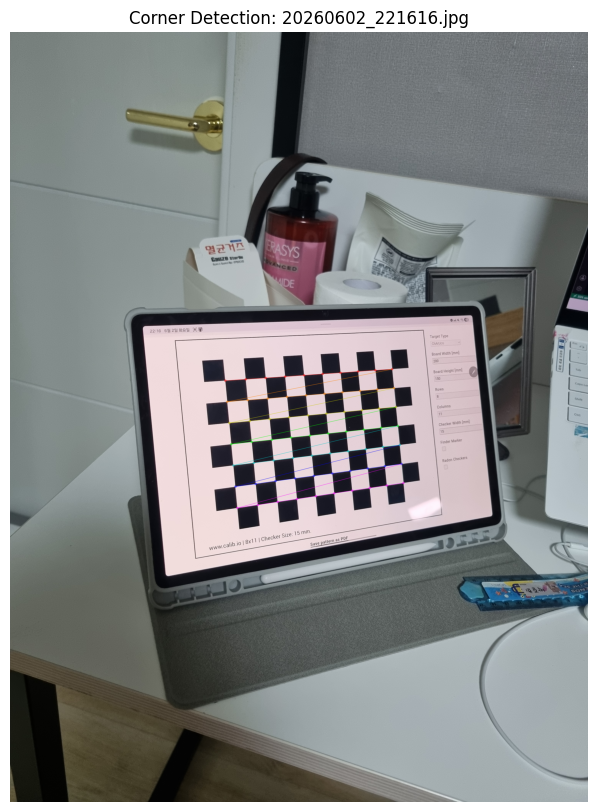

In [20]:
## Code Cell 4: 한 장에서 Corner Detection 확인

# 첫 번째 이미지로 테스트
test_image_path = image_paths[0]

img = cv2.imread(str(test_image_path))
if img is None:
    raise FileNotFoundError(f"Failed to load image: {test_image_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # 흑백으로 변환

ret, corners = cv2.findChessboardCorners(gray, pattern_size)

print("Test image:", test_image_path.name)
print("Detection success:", ret)

if ret:
    print("corners shape:", corners.shape)

    # Refine corner location
    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        30,
        0.001
    )

    corners_refined = cv2.cornerSubPix(
        gray,
        corners,
        winSize=(11, 11),
        zeroZone=(-1, -1),
        criteria=criteria
    )

    img_draw = img.copy()
    cv2.drawChessboardCorners(img_draw, pattern_size, corners_refined, ret)

    # BGR -> RGB for matplotlib
    img_draw_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 10))
    plt.imshow(img_draw_rgb)
    plt.title(f"Corner Detection: {test_image_path.name}")
    plt.axis("off")
    plt.show()
else:
    print("Checkerboard corners were not found.")

## 5. 여러 장 이미지에서 Corner Detection 실행하기

Calibration에서는 여러 장의 이미지에서 검출된 corner를 사용한다.

이미지마다 다음 작업을 반복한다.

```text
1. 이미지 읽기
2. grayscale 변환
3. cv2.findChessboardCorners 실행
4. 성공하면 object points 저장
5. 성공하면 image points 저장
6. corner가 그려진 결과 이미지 저장
7. 실패하면 실패 목록에 기록

In [ ]:
## Code Cell 5: 전체 이미지 Corner Detection

criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

objpoints = []  # 3D points in checkerboard coordinate
imgpoints = []  # 2D points in image pixel coordinate

success_images = []
failed_images = []
rotated_images = []

image_size = None  # (width, height)
for image_path in image_paths:
    img = cv2.imread(str(image_path))

    if img is None:
        failed_images.append((image_path.name, "failed_to_load"))
        continue

    h, w = img.shape[:2]

    # 처음 calibration에서는 landscape 이미지는 제외 버전
    if w > h:
        failed_images.append((image_path.name, "landscape_excluded"))
        continue
    
    # # 로테이션 하는 버전
    # if w > h:
    #     img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    #     rotated_images.append(image_path.name)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape[:2]
    current_image_size = (w, h)

    if image_size is None:
        image_size = current_image_size
    elif image_size != current_image_size:
        failed_images.append((image_path.name, f"image_size_mismatch: {current_image_size}"))
        continue

    ret, corners = cv2.findChessboardCorners(gray, pattern_size)
    
    if ret:
        corners_refined = cv2.cornerSubPix(
            gray,
            corners,
            winSize=(11, 11),
            zeroZone=(-1, -1),
            criteria=criteria
        )

        objpoints.append(objp.copy())
        imgpoints.append(corners_refined)

        success_images.append(image_path.name)

        img_draw = img.copy()
        cv2.drawChessboardCorners(img_draw, pattern_size, corners_refined, ret)

        save_path = result_dir / f"{image_path.stem}_corners.jpg"
        cv2.imwrite(str(save_path), img_draw)

    else:
        failed_images.append((image_path.name, "corners_not_found"))

print("Image size:", image_size)
print("Number of input images:", len(image_paths))
print("Success:", len(success_images))
print("Failed:", len(failed_images))

print("\nSuccess images:")
for name in success_images:
    print("-", name)

print("\nFailed images:")
for name, reason in failed_images:
    print("-", name, "|", reason)

Image size: (3024, 4032)
Number of input images: 14
Success: 11
Failed: 3

Success images:
- 20260602_221616.jpg
- 20260602_221624.jpg
- 20260602_221628.jpg
- 20260602_221636.jpg
- 20260602_221641.jpg
- 20260602_221650.jpg
- 20260602_221655.jpg
- 20260602_221712.jpg
- 20260602_221718.jpg
- 20260602_221724.jpg
- 20260602_221818.jpg

Failed images:
- 20260602_221644.jpg | landscape_excluded
- 20260602_221646.jpg | landscape_excluded
- 20260602_221704.jpg | landscape_excluded


Number of result images: 14


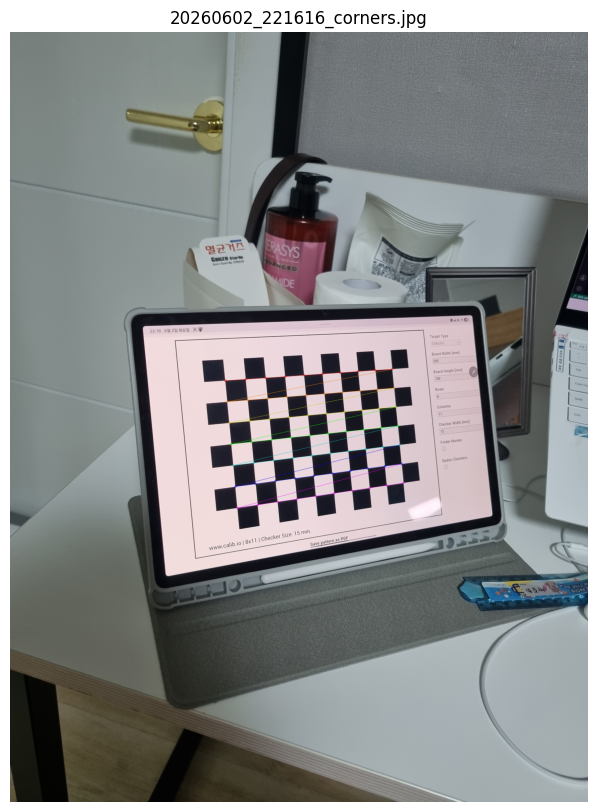

In [24]:
result_paths = sorted(result_dir.glob("*_corners.jpg"))

print("Number of result images:", len(result_paths))

if len(result_paths) > 0:
    result_img = cv2.imread(str(result_paths[0]))
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 10))
    plt.imshow(result_img_rgb)
    plt.title(result_paths[0].name)
    plt.axis("off")
    plt.show()
else:
    print("No result images found.")

## 6. 결과 해석

오늘 저장된 핵심 데이터는 다음이다.

```python
objpoints
imgpoints
image_size
success_images
failed_images
```
각 변수의 의미는 다음과 같다.

objpoints:
여러 이미지에 대해 반복 저장된 checkerboard 3D object points

imgpoints:
각 이미지에서 검출된 checkerboard 2D image points

image_size:
calibration 이미지의 크기
OpenCV calibrateCamera에는 (width, height) 순서로 들어간다

success_images:
corner detection이 성공한 이미지 목록

failed_images:
corner detection이 실패한 이미지 목록

objpoints와 imgpoints는 Day 4의 cv2.calibrateCamera에 그대로 들어간다.


In [25]:
## Code Cell 7: Detection 결과 저장

save_npz_path = result_dir / "corner_detection_data.npz"

np.savez(
    save_npz_path,
    objpoints=np.array(objpoints, dtype=object),
    imgpoints=np.array(imgpoints, dtype=object),
    image_size=np.array(image_size),
    success_images=np.array(success_images),
    failed_images=np.array(failed_images, dtype=object),
    pattern_size=np.array(pattern_size),
    square_size=np.array(square_size)
)

print("Saved:", save_npz_path)

Saved: /mnt/d/6d-pose-estimation-sprint/outputs/week2/corner_detection/corner_detection_data.npz


## 7. Day 3에서 확인해야 하는 것

오늘 확인해야 하는 것은 다음이다.

```text
1. calibration 이미지가 제대로 로드되는가
2. image size가 모두 같은가
3. pattern_size = (10, 7)이 맞는가
4. cv2.findChessboardCorners가 성공하는가
5. corners shape이 (70, 1, 2)로 나오는가
6. corner가 그려진 이미지가 실제 checkerboard와 잘 맞는가
7. 실패 이미지가 있다면 왜 실패했는가

현재 pattern size는 다음과 같다.

pattern_size = (10, 7)

따라서 검출되어야 하는 corner 개수는 다음과 같다.

10 * 7 = 70

검출 성공 시 corners.shape는 보통 다음과 같다.

(70, 1, 2)

---

## Markdown Cell 9: 오늘의 핵심 정리

```markdown
## 8. 오늘의 핵심 정리

오늘은 OpenCV를 이용해 checkerboard calibration 이미지에서 inner corner를 검출했다.

`cv2.findChessboardCorners`는 grayscale image와 `pattern_size`를 입력받아 checkerboard의 2D image points를 찾는다.

Calibration에서 `object points`는 실제 checkerboard 평면 위 inner corner의 3D 좌표이고, `image points`는 이미지에서 검출된 inner corner의 2D pixel 좌표이다.

현재 checkerboard 설정은 다음과 같다.

```python
pattern_size = (10, 7)
square_size = 15.0  # mm

따라서 한 이미지에서 검출되어야 하는 inner corner 수는 70개이다.

검출에 성공한 이미지의 objpoints와 imgpoints는 Day 4의 cv2.calibrateCamera 입력으로 사용된다.

1. 개념 정의 문제

Q. cv2.findChessboardCorners는 무엇을 하는 함수인가?

A.
cv2.findChessboardCorners는 grayscale image에서 checkerboard의 inner corner들을 찾아 2D pixel coordinate로 반환하는 함수이다.

즉, calibration에 필요한 observed image points를 검출한다.

2. 6D Pose Pipeline 연결 문제

Q. Image points는 이후 PnP와 어떻게 연결되는가?

A.
Image points는 이미지에서 검출한 2D pixel coordinate이다.

Camera calibration에서는 checkerboard의 3D object points와 2D image points의 대응을 이용해 camera matrix와 distortion coefficients를 추정한다.

Week 3 PnP에서도 같은 구조가 사용된다.

3D object points
+
2D image points
+
camera matrix K
+
dist_coeffs
-> solvePnP
-> object-to-camera pose R, t
3. Object point 생성 문제

Q. objp는 무엇이며 shape은 어떻게 되는가?

A.
objp는 checkerboard frame에서 정의한 3D object points이다.

수님의 설정에서는 inner corner가 10 x 7개이므로 총 70개의 3D point가 생성된다.

objp.shape = (70, 3)

Checkerboard는 평면이므로 모든 점의 Z=0이다.

좌표 단위는 square_size를 곱했기 때문에 mm이다.

4. Shape 확인 문제

Q. corners.shape = (70, 1, 2)는 무엇을 의미하는가?

A.
corners는 이미지에서 검출된 checkerboard inner corner의 2D pixel 좌표이다.

corners.shape = (70, 1, 2)

여기서 70은 corner 개수이고, 마지막 2는 각 corner의 pixel coordinate인 [u, v]를 의미한다.

5. 디버깅 문제

Q. Corner detection이 실패하는 원인 3가지를 말하라.

A.
Corner detection 실패 원인으로는 pattern_size를 잘못 설정한 경우가 있다.

또한 이미지가 blur 되었거나 checkerboard에 반사가 심한 경우 corner 위치를 안정적으로 찾기 어렵다.

Checkerboard가 이미지 밖으로 잘렸거나 너무 작게 찍힌 경우에도 detection이 실패할 수 있다.

6. README 설명 문제

Q. 오늘 배운 내용을 README에 3문장으로 정리하라.

A.
Week 2 Day 3에서는 cv2.findChessboardCorners를 이용해 calibration image에서 checkerboard의 2D image points를 검출했다.

Checkerboard의 3D object points는 pattern_size = (10, 7)과 square_size = 15.0 mm를 이용해 생성했으며, shape은 (70, 3)이다.

검출된 image points와 미리 정의한 object points의 대응은 Day 4 camera calibration의 입력으로 사용된다.

## Day 4: Camera Calibration 수행

* 목표

    * OpenCV camera calibration을 수행하여 camera matrix와 distortion coefficient를 얻습니다.

* 할 일

    * `cv2.calibrateCamera` 실행
    * camera matrix `K` 출력
    * distortion coefficients 출력
    * rotation vector, translation vector 출력 형식 확인
    * calibration 결과 저장

* 산출물

    * `outputs/calibration/camera_matrix.npy`
    * `outputs/calibration/dist_coeffs.npy`
    * calibration 실험 로그

이번 Day의 목표는 Day 3에서 검출한 checkerboard corner를 이용해 camera calibration을 수행하는 것이다.

Day 3에서 준비한 입력은 다음이다.

```python
objpoints   # checkerboard inner corner의 3D object points
imgpoints   # 이미지에서 검출된 2D image points
image_size  # calibration 이미지 크기, (width, height)
```
오늘은 이 값들을 cv2.calibrateCamera에 넣어서 다음 결과를 얻는다.

```python
camera_matrix  # intrinsic matrix K
dist_coeffs    # distortion coefficients
rvecs          # 각 calibration image에서 checkerboard의 rotation vector
tvecs          # 각 calibration image에서 checkerboard의 translation vector
```
오늘의 핵심 질문은 다음이다.

checkerboard의 3D object points와 이미지에서 검출한 2D image points를 이용해 camera matrix K를 어떻게 추정하는가?

## 1. 오늘 배울 개념

오늘은 다음 개념을 다룬다.

- `cv2.calibrateCamera`
- camera matrix `K`
- distortion coefficients
- rotation vector `rvec`
- translation vector `tvec`
- calibration RMS error
- calibration 결과 저장

오늘은 아직 reprojection error를 이미지별로 자세히 분석하지 않는다.  
Day 5에서 `cv2.projectPoints`를 이용해 reprojection error를 직접 계산한다.

## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization
```

오늘은 Camera Calibration 단계의 핵심 결과물인 K와 dist_coeffs를 얻는다.

이 값들은 이후 다음 단계에서 사용된다.

Week 3 PnP:
3D object point + 2D image point + K + dist_coeffs
-> object-to-camera pose T_co 추정

Week 4 RGB-D / Point Cloud:
depth pixel + K
-> camera frame의 3D point 복원

Week 5 이후 ICP:
camera frame 기준 point cloud 생성에 K가 사용됨

즉, 오늘 얻는 K는 이후 6D pose pipeline 전체에서 카메라 모델의 기준이 된다.

## 3. `cv2.calibrateCamera` 입력과 출력

OpenCV calibration 함수는 다음 형태로 사용한다.

```python
ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    image_size,
    None,
    None
)
```
각 입력의 의미는 다음과 같다.

objpoints:
여러 이미지에 대해 저장된 checkerboard 3D object points

imgpoints:
여러 이미지에서 검출된 checkerboard 2D image points

image_size:
이미지 크기, OpenCV에서는 (width, height) 순서

각 출력의 의미는 다음과 같다.

ret:
전체 calibration의 RMS reprojection error

camera_matrix:
camera intrinsic matrix K

dist_coeffs:
lens distortion coefficients

rvecs:
각 이미지에서 checkerboard pose의 rotation vector

tvecs:
각 이미지에서 checkerboard pose의 translation vector

주의할 점은 rvecs, tvecs가 최종 object 6D pose가 아니라는 것이다.
여기서의 rvecs, tvecs는 calibration 이미지마다 checkerboard가 camera frame에서 어떤 위치와 방향에 있었는지를 나타내는 값이다.


OpenCV 문서에서도 `rvecs`, `tvecs`는 각 pattern view에 대해 추정되며, 해당 rotation/translation이 calibration pattern coordinate에서 camera coordinate로 가는 변환이라고 설명합니다. :contentReference[oaicite:1]{index=1}

## 4. Camera Matrix K의 형태

Calibration 결과로 얻는 camera matrix `K`는 다음 형태이다.

```text
K = [[fx,  0, cx],
     [ 0, fy, cy],
     [ 0,  0,  1]]
```

각 값의 의미는 다음과 같다.

```text
fx, fy:
pixel 단위 focal length

cx, cy:
principal point의 pixel coordinate
```

OpenCV 문서에서도 camera intrinsic matrix는 `fx`, `fy`, `cx`, `cy`로 구성되며, `fx`, `fy`는 pixel 단위 focal length이고 principal point는 보통 이미지 중심 근처에 있다고 설명한다.
```

OpenCV의 pinhole camera model 설명에 따르면 intrinsic matrix는 `fx`, `fy`, `cx`, `cy`로 구성되고, camera coordinate의 3D point를 image plane의 pixel coordinate로 투영하는 데 사용됩니다. :contentReference[oaicite:2]{index=2}



In [3]:
## Code Cell 1: 라이브러리와 경로 설정

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths
corner_data_path = Path("/mnt/d/6d-pose-estimation-sprint/outputs/week2/corner_detection/corner_detection_data.npz")
calib_output_dir = Path("/mnt/d/6d-pose-estimation-sprint/outputs/calibration")
calib_output_dir.mkdir(parents=True, exist_ok=True)

print("corner_data_path:", corner_data_path)
print("calib_output_dir:", calib_output_dir)

corner_data_path: /mnt/d/6d-pose-estimation-sprint/outputs/week2/corner_detection/corner_detection_data.npz
calib_output_dir: /mnt/d/6d-pose-estimation-sprint/outputs/calibration


In [8]:
## Code Cell 2: Day 3 결과 불러오기
data = np.load(corner_data_path, allow_pickle=True)

# npz에서 object array로 저장된 것을 다시 OpenCV가 받을 수 있는 float32 list로 변환
objpoints_raw = data["objpoints"]
imgpoints_raw = data["imgpoints"]

objpoints = [
    np.asarray(p, dtype=np.float32).reshape(-1, 3)
    for p in objpoints_raw
]

imgpoints = [
    np.asarray(p, dtype=np.float32).reshape(-1, 1, 2)
    for p in imgpoints_raw
]

image_size = tuple(int(x) for x in data["image_size"].tolist())
pattern_size = tuple(int(x) for x in data["pattern_size"].tolist())
square_size = float(data["square_size"])

success_images = list(data["success_images"])
failed_images = list(data["failed_images"])

print("Loaded corner detection data")
print("Number of objpoints:", len(objpoints))
print("Number of imgpoints:", len(imgpoints))
print("image_size:", image_size)
print("pattern_size:", pattern_size)
print("square_size:", square_size)

print("\nFirst objpoints:")
print(type(objpoints[0]), objpoints[0].dtype, objpoints[0].shape)

print("\nFirst imgpoints:")
print(type(imgpoints[0]), imgpoints[0].dtype, imgpoints[0].shape)

Loaded corner detection data
Number of objpoints: 11
Number of imgpoints: 11
image_size: (3024, 4032)
pattern_size: (10, 7)
square_size: 15.0

First objpoints:
<class 'numpy.ndarray'> float32 (70, 3)

First imgpoints:
<class 'numpy.ndarray'> float32 (70, 1, 2)


In [9]:
## Code Cell 3: 입력 데이터 shape 확인

print("Checking calibration inputs...\n")

print("Number of views:", len(objpoints))

for i in range(min(3, len(objpoints))):
    print(f"View {i}")
    print("  objpoints shape:", objpoints[i].shape)
    print("  imgpoints shape:", imgpoints[i].shape)

if len(objpoints) != len(imgpoints):
    raise ValueError("objpoints and imgpoints must have the same number of views.")

if len(objpoints) < 10:
    print("Warning: calibration image count is less than 10. More images are usually better.")

print("\nInput check done.")

Checking calibration inputs...

Number of views: 11
View 0
  objpoints shape: (70, 3)
  imgpoints shape: (70, 1, 2)
View 1
  objpoints shape: (70, 3)
  imgpoints shape: (70, 1, 2)
View 2
  objpoints shape: (70, 3)
  imgpoints shape: (70, 1, 2)

Input check done.


In [ ]:
## Code Cell 4: Camera Calibration 실행

ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    image_size,
    None,
    None
)

print("Calibration done.")
print("RMS reprojection error returned by calibrateCamera:", ret)
# calibration 결과로 다시 checkerboard corner를 이미지에 투영했을 때 평균적으로 0.3 pixel 정도의 오차

print("\nCamera matrix K:")
print(camera_matrix)

print("\nDistortion coefficients:")
print(dist_coeffs)
# [k1, k2, p1, p2, k3]
# k1, k2, k3 = radial distortion
# p1, p2 = tangential distortion

print("\nNumber of rvecs:", len(rvecs))
print("Number of tvecs:", len(tvecs))

print("\nFirst rvec:")
print(rvecs[0])

print("\nFirst tvec:")
print(tvecs[0])
# mm단위임
# z가 41.1cm정도가 나왔으니 어느정도 맞음.
# Day 4의 rvecs, tvecs는 최종 물체 pose가 아니라, calibration 이미지마다 checkerboard의 pose이다.

Calibration done.
RMS reprojection error returned by calibrateCamera: 0.29568754071471653

Camera matrix K:
[[3.08598307e+03 0.00000000e+00 1.51504283e+03]
 [0.00000000e+00 3.08298372e+03 2.01107601e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion coefficients:
[[ 0.01643763  0.14300819 -0.00055302  0.00087966 -0.35035006]]

Number of rvecs: 11
Number of tvecs: 11

First rvec:
[[-0.02149473]
 [-0.37315768]
 [-0.09513902]]

First tvec:
[[-52.35677911]
 [-25.04774064]
 [414.57201071]]


## 5. Calibration 결과 해석

`ret`는 OpenCV `calibrateCamera`가 반환하는 전체 RMS reprojection error이다.

값이 작을수록 calibration 결과가 좋다고 볼 수 있다.  
하지만 Day 4에서는 이 값만 보고 최종 판단하지 않는다.

Day 5에서 각 이미지별 reprojection error를 직접 계산하고, error가 큰 이미지를 확인한다.

`camera_matrix`는 이후 계속 사용할 camera intrinsic matrix `K`이다.

`dist_coeffs`는 lens distortion을 보정하기 위한 계수이다.

`rvecs`, `tvecs`는 calibration에 사용된 각 이미지에서 checkerboard가 camera frame 기준으로 어떤 pose를 가졌는지 나타낸다.


In [11]:
## Code Cell 5: K에서 fx, fy, cx, cy 추출

fx = camera_matrix[0, 0]
fy = camera_matrix[1, 1]
cx = camera_matrix[0, 2]
cy = camera_matrix[1, 2]

print("fx:", fx)
print("fy:", fy)
print("cx:", cx)
print("cy:", cy)

print("\nImage size:", image_size)
print("Image center approx:", (image_size[0] / 2, image_size[1] / 2))

fx: 3085.9830737674906
fy: 3082.9837150675844
cx: 1515.0428269100937
cy: 2011.0760117600073

Image size: (3024, 4032)
Image center approx: (1512.0, 2016.0)


## 6. fx, fy, cx, cy sanity check

Calibration 결과를 볼 때 먼저 다음을 확인한다.

```text
1. fx, fy가 양수인가?
2. fx와 fy가 너무 말이 안 되게 다르지 않은가?
3. cx, cy가 이미지 중심 근처에 있는가?
4. dist_coeffs 값이 출력되는가?
5. rvecs, tvecs 개수가 성공 이미지 수와 같은가?
```

현재 이미지 크기가 `3024 x 4032`이면 이미지 중심은 대략 다음과 같다.

```text
cx 근처 예상값: 1512
cy 근처 예상값: 2016
```

단, principal point는 정확히 이미지 중심과 같을 필요는 없다.  
Calibration 결과에서 약간 다르게 나올 수 있다.

In [12]:
## Code Cell 6: 결과 저장

camera_matrix_path = calib_output_dir / "camera_matrix.npy"
dist_coeffs_path = calib_output_dir / "dist_coeffs.npy"
rvecs_path = calib_output_dir / "rvecs.npy"
tvecs_path = calib_output_dir / "tvecs.npy"
calibration_result_path = calib_output_dir / "calibration_result.npz"

np.save(camera_matrix_path, camera_matrix)
np.save(dist_coeffs_path, dist_coeffs)
np.save(rvecs_path, np.array(rvecs))
np.save(tvecs_path, np.array(tvecs))

np.savez(
    calibration_result_path,
    rms_error=ret,
    camera_matrix=camera_matrix,
    dist_coeffs=dist_coeffs,
    rvecs=np.array(rvecs),
    tvecs=np.array(tvecs),
    image_size=np.array(image_size),
    pattern_size=np.array(pattern_size),
    square_size=np.array(square_size),
    success_images=np.array(success_images)
)

print("Saved calibration results:")
print(camera_matrix_path)
print(dist_coeffs_path)
print(rvecs_path)
print(tvecs_path)
print(calibration_result_path)

Saved calibration results:
/mnt/d/6d-pose-estimation-sprint/outputs/calibration/camera_matrix.npy
/mnt/d/6d-pose-estimation-sprint/outputs/calibration/dist_coeffs.npy
/mnt/d/6d-pose-estimation-sprint/outputs/calibration/rvecs.npy
/mnt/d/6d-pose-estimation-sprint/outputs/calibration/tvecs.npy
/mnt/d/6d-pose-estimation-sprint/outputs/calibration/calibration_result.npz


In [13]:
## Code Cell 7: 사람이 읽기 좋은 txt 저장

txt_path = calib_output_dir / "calibration_summary.txt"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write("# Calibration Summary\n\n")
    f.write(f"RMS reprojection error: {ret}\n\n")
    f.write("Camera matrix K:\n")
    f.write(str(camera_matrix))
    f.write("\n\nDistortion coefficients:\n")
    f.write(str(dist_coeffs))
    f.write("\n\n")
    f.write(f"fx: {fx}\n")
    f.write(f"fy: {fy}\n")
    f.write(f"cx: {cx}\n")
    f.write(f"cy: {cy}\n")
    f.write(f"\nImage size: {image_size}\n")
    f.write(f"Pattern size: {pattern_size}\n")
    f.write(f"Square size: {square_size} mm\n")
    f.write(f"Number of calibration views: {len(objpoints)}\n")

print("Saved:", txt_path)

Saved: /mnt/d/6d-pose-estimation-sprint/outputs/calibration/calibration_summary.txt


## 7. 저장된 결과 파일

Day 4에서 저장한 결과 파일은 다음과 같다.

```text
outputs/calibration/camera_matrix.npy
outputs/calibration/dist_coeffs.npy
outputs/calibration/rvecs.npy
outputs/calibration/tvecs.npy
outputs/calibration/calibration_result.npz
outputs/calibration/calibration_summary.txt
```

이 중 가장 중요한 파일은 다음 두 개이다.

```text
camera_matrix.npy
dist_coeffs.npy
```

이 값들은 Week 3 PnP에서 다음처럼 사용된다.

```python
camera_matrix = np.load("outputs/calibration/camera_matrix.npy")
dist_coeffs = np.load("outputs/calibration/dist_coeffs.npy")

ret, rvec, tvec = cv2.solvePnP(
    object_points,
    image_points,
    camera_matrix,
    dist_coeffs
)
```

즉, Day 4의 산출물은 Week 3 PnP의 직접 입력이 된다.
```

---

## Markdown Cell 9

```markdown
## 8. 자주 헷갈리는 점

### 1. `ret`는 최종 pose가 아니다

`ret`는 calibration 결과의 전체 RMS reprojection error이다.  
작을수록 좋지만, Day 5에서 이미지별 reprojection error를 직접 확인해야 한다.

### 2. `rvecs`, `tvecs`는 최종 물체 pose가 아니다

Day 4의 `rvecs`, `tvecs`는 calibration 이미지마다 checkerboard가 camera frame 기준으로 어디에 있었는지를 나타낸다.

즉, 이것은 나중에 추정할 object pose와 같은 개념 구조를 가지지만, 지금은 calibration board의 pose이다.

### 3. `K`는 pose가 아니다

`K`는 camera intrinsic matrix이다.  
물체의 위치와 방향을 나타내는 값은 `R`, `t`, `T`이다.

### 4. `dist_coeffs`는 무시하면 안 된다

렌즈 왜곡이 있는 이미지에서 `dist_coeffs`를 무시하면 projection 위치가 틀어질 수 있다.  
따라서 Week 3 PnP와 `cv2.projectPoints`에서도 `dist_coeffs`를 함께 사용한다.
```

---

## Markdown Cell 10: 오늘의 핵심 정리

```markdown
## 9. 오늘의 핵심 정리

오늘은 Day 3에서 만든 `objpoints`, `imgpoints`, `image_size`를 이용해 `cv2.calibrateCamera`를 실행했다.

Calibration 결과로 camera intrinsic matrix `K`, distortion coefficients, 각 calibration image에 대한 `rvecs`, `tvecs`를 얻었다.

`K`는 다음 형태의 3x3 행렬이다.

```text
K = [[fx,  0, cx],
     [ 0, fy, cy],
     [ 0,  0,  1]]
```

`fx`, `fy`는 pixel 단위 focal length이고, `cx`, `cy`는 principal point의 pixel coordinate이다.

`dist_coeffs`는 렌즈 왜곡을 보정하기 위한 계수이다.

Day 4에서 저장한 `camera_matrix.npy`와 `dist_coeffs.npy`는 Week 3 PnP에서 3D object point와 2D image point를 연결해 pose를 추정할 때 사용된다.


1. 개념 정의 문제

Q. cv2.calibrateCamera는 무엇을 하는 함수인가?

A.
cv2.calibrateCamera는 여러 장의 calibration image에서 얻은 3D object points와 2D image points를 이용해 camera parameters를 추정하는 함수이다.

이 함수는 camera matrix K, distortion coefficients, 각 이미지에서의 checkerboard pose인 rvecs, tvecs, 그리고 RMS reprojection error를 반환한다.

2. 입력/출력 문제

Q. cv2.calibrateCamera의 주요 입력과 출력은 무엇인가?

A.
주요 입력은 다음과 같다.

objpoints
imgpoints
image_size

주요 출력은 다음과 같다.

ret              # RMS reprojection error
camera_matrix    # K
dist_coeffs      # distortion coefficients
rvecs            # 각 이미지의 rotation vector
tvecs            # 각 이미지의 translation vector
3. Camera matrix 해석 문제

Q. Camera matrix에서 fx, fy, cx, cy는 어디에 위치하는가?

A.
Camera matrix는 다음 형태이다.

K = [[fx,  0, cx],
     [ 0, fy, cy],
     [ 0,  0,  1]]

수님의 calibration 결과는 다음과 같았다.

fx = 3085.9831
fy = 3082.9837
cx = 1515.0428
cy = 2011.0760

이미지 크기가 3024 x 4032이므로 principal point는 이미지 중심 근처에 위치해 있다.

4. Pose 해석 문제

Q. rvecs, tvecs는 무엇을 의미하는가?

A.
rvecs, tvecs는 각 calibration image에서 checkerboard frame을 camera frame으로 변환하는 pose를 의미한다.

즉, Day 4에서의 pose는 다음 변환이다.

checkerboard frame -> camera frame

이는 Week 3 PnP에서 object frame 또는 marker frame을 camera frame으로 변환하는 pose와 구조적으로 같다.

다만 Day 4에서는 대상이 checkerboard이고, Week 3에서는 실제 object 또는 marker가 대상이다.

5. 디버깅 문제

Q. objectPoints type error가 발생한 이유는 무엇이며 어떻게 고치는가?

A.
.npz로 저장한 objpoints, imgpoints가 dtype=object 형태로 로드되어 OpenCV가 요구하는 float array list가 아니었기 때문에 오류가 발생했다.

해결 방법은 OpenCV가 받을 수 있는 형태로 다시 변환하는 것이다.

objpoints = [np.asarray(p, dtype=np.float32).reshape(-1, 3) for p in objpoints_raw]
imgpoints = [np.asarray(p, dtype=np.float32).reshape(-1, 1, 2) for p in imgpoints_raw]
6. README 설명 문제

Q. 오늘 배운 내용을 README에 3문장으로 정리하라.

A.
Week 2 Day 4에서는 Day 3에서 검출한 object points와 image points를 이용해 cv2.calibrateCamera로 camera calibration을 수행했다.

Calibration 결과 camera_matrix, dist_coeffs, rvecs, tvecs를 얻었고, RMS reprojection error는 약 0.296 px로 안정적이었다.

추정된 camera_matrix와 dist_coeffs는 이후 undistortion, reprojection error 계산, Week 3 PnP pose estimation에서 사용된다.

## Day 5: Reprojection Error 계산

* 목표

    * calibration 결과가 얼마나 좋은지 reprojection error로 확인합니다.

* 할 일

    * 3D checkerboard point를 이미지로 다시 projection
    * 검출된 2D corner와 projected point 비교
    * 평균 reprojection error 계산
    * error가 큰 이미지 확인
    * error가 큰 원인 후보 기록

* 산출물

    * reprojection error 수치
    * error 분석 노트
    * `error_log.md` 업데이트


이번 Day의 목표는 calibration 결과가 얼마나 좋은지 reprojection error로 확인하는 것이다.

Day 4에서는 `cv2.calibrateCamera`를 이용해 다음 값을 얻었다.

```python
camera_matrix  # K
dist_coeffs
rvecs
tvecs
```
오늘은 이 값을 이용해 checkerboard의 3D object points를 다시 이미지 위로 투영한다.

그다음 실제로 검출된 image points와 다시 투영된 projected points가 얼마나 가까운지 계산한다.

오늘의 핵심 질문은 다음이다.

추정한 camera matrix K, distortion coefficients, rvecs, tvecs가 실제 checkerboard corner를 이미지 위에 얼마나 잘 다시 투영하는가?

## 1. 오늘 배울 개념

오늘은 다음 개념을 다룬다.

- reprojection error
- observed image points
- projected image points
- `cv2.projectPoints`
- image-wise error
- global RMS error
- error가 큰 calibration image 찾기

오늘은 calibration을 다시 하는 것이 아니라, Day 4의 calibration 결과를 평가한다.

## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization
```

오늘은 Camera Calibration 결과를 평가한다.

Reprojection error는 이후 Week 3 PnP에서도 다시 등장한다.

PnP에서도 추정한 pose가 맞는지 확인할 때 다음 과정을 사용한다.

```text
3D object point
-> estimated pose R, t
-> camera matrix K
-> projected 2D point
-> 실제 image point와 비교
```

즉, reprojection error는 "3D 점을 다시 이미지에 찍었을 때 실제 관측된 2D 점과 얼마나 차이 나는가"를 보는 값이다.

## 3. Reprojection Error란 무엇인가

Calibration에서 이미 알고 있는 값은 두 종류이다.

```text
object points:
실제 checkerboard 위 inner corner의 3D 좌표

image points:
이미지에서 검출된 inner corner의 2D pixel 좌표
```

Day 4에서 calibration을 수행하면 각 이미지마다 `rvec`, `tvec`가 나온다.  
이는 해당 이미지에서 checkerboard가 camera frame 기준으로 어떤 pose였는지를 나타낸다.

이제 `object points`를 다음 값들로 다시 이미지에 투영할 수 있다.

```text
object points
+ rvec, tvec
+ camera_matrix K
+ dist_coeffs
-> projected image points
```

그리고 다음 두 점을 비교한다.

```text
observed image points:
cv2.findChessboardCorners로 실제 이미지에서 검출한 corner

projected image points:
cv2.projectPoints로 다시 투영한 corner
```

두 점 사이의 pixel 거리 평균 또는 RMS가 reprojection error이다.

In [1]:
# Code Cell 1: 라이브러리와 경로 설정
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

corner_data_path = Path("outputs/week2/corner_detection/corner_detection_data.npz")
calibration_result_path = Path("outputs/calibration/calibration_result.npz")
image_dir = Path("data/calibration/images")

result_dir = Path("outputs/week2/reprojection_error")
overlay_dir = result_dir / "overlays"
result_dir.mkdir(parents=True, exist_ok=True)
overlay_dir.mkdir(parents=True, exist_ok=True)

print("corner_data_path:", corner_data_path)
print("calibration_result_path:", calibration_result_path)
print("image_dir:", image_dir)
print("result_dir:", result_dir)

corner_data_path: outputs/week2/corner_detection/corner_detection_data.npz
calibration_result_path: outputs/calibration/calibration_result.npz
image_dir: data/calibration/images
result_dir: outputs/week2/reprojection_error


In [2]:
# Code Cell 2: Day 3 / Day 4 결과 불러오기
if not corner_data_path.exists():
    raise FileNotFoundError(f"Not found: {corner_data_path}")

if not calibration_result_path.exists():
    raise FileNotFoundError(f"Not found: {calibration_result_path}")

corner_data = np.load(corner_data_path, allow_pickle=True)
calib_data = np.load(calibration_result_path, allow_pickle=True)

# Day 3 data
objpoints_raw = corner_data["objpoints"]
imgpoints_raw = corner_data["imgpoints"]

objpoints = [
    np.asarray(p, dtype=np.float32).reshape(-1, 3)
    for p in objpoints_raw
]

imgpoints = [
    np.asarray(p, dtype=np.float32).reshape(-1, 1, 2)
    for p in imgpoints_raw
]

image_size = tuple(int(x) for x in corner_data["image_size"].tolist())
success_images = [str(x) for x in corner_data["success_images"].tolist()]

# Day 4 calibration result
camera_matrix = np.asarray(calib_data["camera_matrix"], dtype=np.float64)
dist_coeffs = np.asarray(calib_data["dist_coeffs"], dtype=np.float64)
rvecs = [np.asarray(r, dtype=np.float64).reshape(3, 1) for r in calib_data["rvecs"]]
tvecs = [np.asarray(t, dtype=np.float64).reshape(3, 1) for t in calib_data["tvecs"]]
rms_from_calibrate_camera = float(calib_data["rms_error"])

print("Number of views:", len(objpoints))
print("Number of image points:", len(imgpoints))
print("Number of rvecs:", len(rvecs))
print("Number of tvecs:", len(tvecs))
print("image_size:", image_size)

print("\nRMS from calibrateCamera:", rms_from_calibrate_camera)
print("\nCamera matrix K:")
print(camera_matrix)

print("\nDistortion coefficients:")
print(dist_coeffs)

Number of views: 11
Number of image points: 11
Number of rvecs: 11
Number of tvecs: 11
image_size: (3024, 4032)

RMS from calibrateCamera: 0.29568754071471653

Camera matrix K:
[[3.08598307e+03 0.00000000e+00 1.51504283e+03]
 [0.00000000e+00 3.08298372e+03 2.01107601e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion coefficients:
[[ 0.01643763  0.14300819 -0.00055302  0.00087966 -0.35035006]]


In [3]:
# Code Cell 3: 입력 개수 확인
n_views = len(objpoints)

if not (len(objpoints) == len(imgpoints) == len(rvecs) == len(tvecs)):
    raise ValueError(
        "objpoints, imgpoints, rvecs, tvecs must have the same number of views."
    )

print("Input count check passed.")
print("Number of calibration views:", n_views)

for i in range(min(3, n_views)):
    print(f"\nView {i}")
    print("  objpoints:", objpoints[i].shape, objpoints[i].dtype)
    print("  imgpoints:", imgpoints[i].shape, imgpoints[i].dtype)
    print("  rvec:", rvecs[i].shape, rvecs[i].dtype)
    print("  tvec:", tvecs[i].shape, tvecs[i].dtype)

Input count check passed.
Number of calibration views: 11

View 0
  objpoints: (70, 3) float32
  imgpoints: (70, 1, 2) float32
  rvec: (3, 1) float64
  tvec: (3, 1) float64

View 1
  objpoints: (70, 3) float32
  imgpoints: (70, 1, 2) float32
  rvec: (3, 1) float64
  tvec: (3, 1) float64

View 2
  objpoints: (70, 3) float32
  imgpoints: (70, 1, 2) float32
  rvec: (3, 1) float64
  tvec: (3, 1) float64


## 4. `cv2.projectPoints`로 다시 투영하기

각 calibration image마다 다음을 수행한다.

```text
1. object points를 가져온다.
2. 해당 이미지의 rvec, tvec을 가져온다.
3. camera_matrix K와 dist_coeffs를 넣는다.
4. cv2.projectPoints로 projected points를 계산한다.
5. detected image points와 projected points 사이의 pixel error를 계산한다.
```

여기서 중요한 점은 `cv2.projectPoints`가 3D point를 2D image pixel coordinate로 보내는 함수라는 것이다.

즉, Day 5의 흐름은 다음이다.

```text
object points
-> rvec, tvec
-> camera frame
-> K, dist_coeffs
-> projected image points
```

In [4]:
# Code Cell 4: 이미지별 Reprojection Error 계산
per_image_results = []

total_squared_error = 0.0
total_point_count = 0

for i in range(n_views):
    projected_points, _ = cv2.projectPoints(
        objpoints[i],
        rvecs[i],
        tvecs[i],
        camera_matrix,
        dist_coeffs
    )

    observed = imgpoints[i].reshape(-1, 2)
    projected = projected_points.reshape(-1, 2)

    diff = observed - projected
    point_errors = np.linalg.norm(diff, axis=1)

    mean_error = float(np.mean(point_errors))
    rms_error = float(np.sqrt(np.mean(point_errors ** 2)))
    max_error = float(np.max(point_errors))

    total_squared_error += float(np.sum(point_errors ** 2))
    total_point_count += len(point_errors)

    image_name = success_images[i] if i < len(success_images) else f"view_{i}"

    per_image_results.append({
        "index": i,
        "image_name": image_name,
        "mean_error_px": mean_error,
        "rms_error_px": rms_error,
        "max_error_px": max_error,
        "num_points": len(point_errors),
    })

global_rmse = np.sqrt(total_squared_error / total_point_count)

print("Global RMSE reprojection error:", global_rmse)
print("RMS from cv2.calibrateCamera:", rms_from_calibrate_camera)

print("\nPer-image reprojection error:")
for r in per_image_results:
    print(
        f"{r['index']:02d} | {r['image_name']} | "
        f"mean={r['mean_error_px']:.4f}px | "
        f"rmse={r['rms_error_px']:.4f}px | "
        f"max={r['max_error_px']:.4f}px"
    )

Global RMSE reprojection error: 0.29568838170350475
RMS from cv2.calibrateCamera: 0.29568754071471653

Per-image reprojection error:
00 | 20260602_221616.jpg | mean=0.3009px | rmse=0.3461px | max=1.0402px
01 | 20260602_221624.jpg | mean=0.3825px | rmse=0.4342px | max=1.1083px
02 | 20260602_221628.jpg | mean=0.1660px | rmse=0.1820px | max=0.3946px
03 | 20260602_221636.jpg | mean=0.1969px | rmse=0.2251px | max=0.6497px
04 | 20260602_221641.jpg | mean=0.2441px | rmse=0.2703px | max=0.5503px
05 | 20260602_221650.jpg | mean=0.3125px | rmse=0.3485px | max=0.8591px
06 | 20260602_221655.jpg | mean=0.1789px | rmse=0.2002px | max=0.4422px
07 | 20260602_221712.jpg | mean=0.2892px | rmse=0.3287px | max=0.7282px
08 | 20260602_221718.jpg | mean=0.2735px | rmse=0.3127px | max=0.9240px
09 | 20260602_221724.jpg | mean=0.2535px | rmse=0.3046px | max=0.9117px
10 | 20260602_221818.jpg | mean=0.1615px | rmse=0.1909px | max=0.6067px


In [5]:
# Code Cell 5: Error 큰 이미지 순서로 정렬
sorted_results = sorted(
    per_image_results,
    key=lambda x: x["rms_error_px"],
    reverse=True
)

print("Images sorted by RMS reprojection error:\n")

for r in sorted_results:
    print(
        f"{r['index']:02d} | {r['image_name']} | "
        f"rmse={r['rms_error_px']:.4f}px | "
        f"mean={r['mean_error_px']:.4f}px | "
        f"max={r['max_error_px']:.4f}px"
    )

Images sorted by RMS reprojection error:

01 | 20260602_221624.jpg | rmse=0.4342px | mean=0.3825px | max=1.1083px
05 | 20260602_221650.jpg | rmse=0.3485px | mean=0.3125px | max=0.8591px
00 | 20260602_221616.jpg | rmse=0.3461px | mean=0.3009px | max=1.0402px
07 | 20260602_221712.jpg | rmse=0.3287px | mean=0.2892px | max=0.7282px
08 | 20260602_221718.jpg | rmse=0.3127px | mean=0.2735px | max=0.9240px
09 | 20260602_221724.jpg | rmse=0.3046px | mean=0.2535px | max=0.9117px
04 | 20260602_221641.jpg | rmse=0.2703px | mean=0.2441px | max=0.5503px
03 | 20260602_221636.jpg | rmse=0.2251px | mean=0.1969px | max=0.6497px
06 | 20260602_221655.jpg | rmse=0.2002px | mean=0.1789px | max=0.4422px
10 | 20260602_221818.jpg | rmse=0.1909px | mean=0.1615px | max=0.6067px
02 | 20260602_221628.jpg | rmse=0.1820px | mean=0.1660px | max=0.3946px


In [6]:
# Code Cell 6: CSV로 저장
csv_path = result_dir / "reprojection_errors.csv"

with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "index",
            "image_name",
            "mean_error_px",
            "rms_error_px",
            "max_error_px",
            "num_points",
        ]
    )
    writer.writeheader()
    writer.writerows(per_image_results)

print("Saved:", csv_path)

Saved: outputs/week2/reprojection_error/reprojection_errors.csv


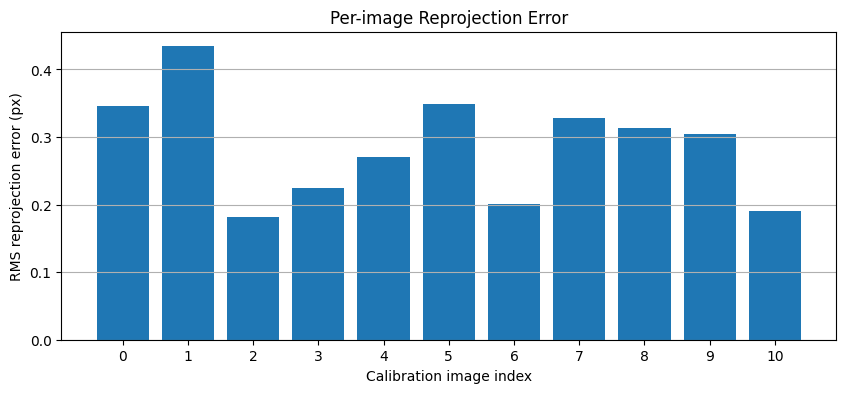

In [7]:
# Code Cell 7: Reprojection Error 그래프
indices = [r["index"] for r in per_image_results]
rmse_values = [r["rms_error_px"] for r in per_image_results]

plt.figure(figsize=(10, 4))
plt.bar(indices, rmse_values)
plt.xlabel("Calibration image index")
plt.ylabel("RMS reprojection error (px)")
plt.title("Per-image Reprojection Error")
plt.xticks(indices)
plt.grid(axis="y")
plt.show()

## 5. Error 결과 해석 기준

Reprojection error는 pixel 단위이다.

현재 calibration 결과에서 Day 4의 RMS error가 약 `0.296 px`였으므로, Day 5에서 직접 계산한 global RMSE도 비슷하게 나와야 한다.

일반적으로 다음처럼 해석한다.

```text
0.3 px 근처:
현재 실습용 calibration으로는 좋은 결과

1 px 이상:
사용할 수는 있지만, 이미지별 error를 확인하는 것이 좋음

2 px 이상:
pattern_size, corner detection, image quality, image_size 등을 의심해야 함

다만 절대 기준은 데이터, 카메라, 해상도, calibration target 품질에 따라 달라진다.

중요한 것은 전체 평균만 보는 것이 아니라, 이미지별 error가 유독 큰 이미지가 있는지 확인하는 것이다.

In [8]:
## Code Cell 8: Observed vs Projected Points 시각화 저장

def draw_observed_and_projected(image, observed_points, projected_points):
    img_draw = image.copy()

    observed = observed_points.reshape(-1, 2)
    projected = projected_points.reshape(-1, 2)

    for obs, proj in zip(observed, projected):
        u_obs, v_obs = int(round(obs[0])), int(round(obs[1]))
        u_proj, v_proj = int(round(proj[0])), int(round(proj[1]))

        # observed: green, projected: red
        cv2.circle(img_draw, (u_obs, v_obs), 8, (0, 255, 0), -1)
        cv2.circle(img_draw, (u_proj, v_proj), 5, (0, 0, 255), -1)

    return img_draw


for i in range(n_views):
    image_name = success_images[i]
    image_path = image_dir / image_name

    img = cv2.imread(str(image_path))
    if img is None:
        print("Failed to load:", image_path)
        continue

    # Day 3에서 landscape 이미지는 제외했으므로 여기서는 회전 처리하지 않는다.
    projected_points, _ = cv2.projectPoints(
        objpoints[i],
        rvecs[i],
        tvecs[i],
        camera_matrix,
        dist_coeffs
    )

    img_overlay = draw_observed_and_projected(
        img,
        imgpoints[i],
        projected_points
    )

    save_path = overlay_dir / f"{Path(image_name).stem}_reprojection_overlay.jpg"
    cv2.imwrite(str(save_path), img_overlay)

print("Saved overlay images to:", overlay_dir)

Saved overlay images to: outputs/week2/reprojection_error/overlays


Worst image:
{'index': 1, 'image_name': '20260602_221624.jpg', 'mean_error_px': 0.3824998438358307, 'rms_error_px': 0.43417075276374817, 'max_error_px': 1.1082546710968018, 'num_points': 70}


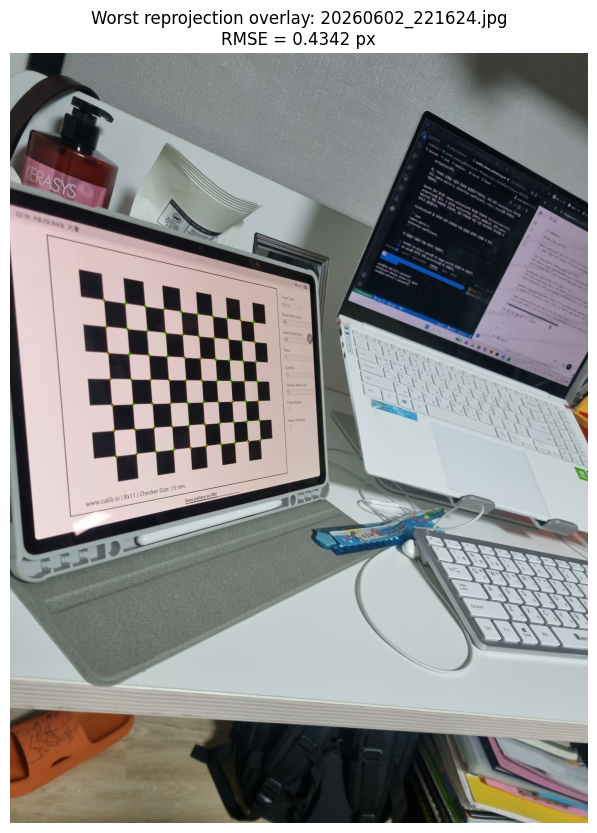

In [9]:
# Code Cell 9: Error 가장 큰 이미지 확인
worst = sorted_results[0]
worst_index = worst["index"]
worst_image_name = worst["image_name"]

overlay_path = overlay_dir / f"{Path(worst_image_name).stem}_reprojection_overlay.jpg"

print("Worst image:")
print(worst)

img = cv2.imread(str(overlay_path))

if img is None:
    print("Failed to load overlay:", overlay_path)
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 10))
    plt.imshow(img_rgb)
    plt.title(
        f"Worst reprojection overlay: {worst_image_name}\n"
        f"RMSE = {worst['rms_error_px']:.4f} px"
    )
    plt.axis("off")
    plt.show()

## 6. Overlay 결과 해석

Overlay 이미지에서는 두 종류의 점을 비교한다.

```text
초록 점:
cv2.findChessboardCorners로 실제 이미지에서 검출한 observed corner

빨간 점:
cv2.projectPoints로 다시 투영한 projected corner

두 점이 거의 겹치면 calibration 결과가 해당 이미지에서 잘 맞는 것이다.

두 점이 한쪽 방향으로 일정하게 밀려 있으면 cx, cy, image_size, 이미지 방향 처리 문제를 의심할 수 있다.

가장자리에서만 오차가 커지면 distortion coefficient나 corner detection 품질을 의심할 수 있다.

특정 이미지 하나만 오차가 크면 반사, blur, corner detection 오류, 체커보드 일부 잘림 등을 의심한다.

In [10]:
## Code Cell 10: Summary txt 저장

summary_path = result_dir / "reprojection_error_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("# Reprojection Error Summary\n\n")
    f.write(f"Global RMSE reprojection error: {global_rmse:.6f} px\n")
    f.write(f"RMS from cv2.calibrateCamera: {rms_from_calibrate_camera:.6f} px\n")
    f.write(f"Number of views: {n_views}\n")
    f.write(f"Image size: {image_size}\n\n")

    f.write("Per-image results:\n")
    for r in per_image_results:
        f.write(
            f"{r['index']:02d} | {r['image_name']} | "
            f"mean={r['mean_error_px']:.6f}px | "
            f"rmse={r['rms_error_px']:.6f}px | "
            f"max={r['max_error_px']:.6f}px\n"
        )

    f.write("\nWorst image:\n")
    f.write(str(worst))

print("Saved:", summary_path)

Saved: outputs/week2/reprojection_error/reprojection_error_summary.txt


## 7. Day 5에서 확인해야 하는 것

오늘 확인해야 하는 것은 다음이다.

```text
1. global RMSE가 Day 4의 ret와 비슷한가
2. 이미지별 RMS error가 유독 큰 이미지가 있는가
3. worst image의 overlay에서 observed point와 projected point가 얼마나 차이 나는가
4. error가 큰 이미지의 원인 후보가 무엇인가
5. calibration 결과를 그대로 쓸지, 특정 이미지를 제외하고 다시 calibration할지 판단할 수 있는가
```
Day 5 결과가 좋으면 Day 6에서 image undistortion을 진행한다.


---


## 8. 오늘의 핵심 정리

오늘은 Day 4에서 얻은 calibration 결과를 reprojection error로 평가했다.

`cv2.projectPoints`를 이용해 checkerboard의 3D object points를 다시 image pixel coordinate로 투영했고, 이를 실제로 검출된 image points와 비교했다.

Reprojection error는 projected point와 observed point 사이의 pixel distance이다.

이 값이 작을수록 calibration 결과가 실제 이미지의 checkerboard corner를 잘 설명한다고 볼 수 있다.

전체 RMS error뿐 아니라 이미지별 RMS error를 확인해야 한다.

특정 이미지에서만 error가 크다면 해당 이미지의 반사, blur, corner detection 오류, 잘림, 방향 처리 문제 등을 의심해야 한다.

Day 5에서 계산한 reprojection error는 Week 3 PnP에서도 pose 결과를 평가하는 핵심 기준으로 다시 사용된다.

1. 개념 정의 문제

Q. Reprojection error는 무엇인가?

A.
Reprojection error는 3D object point를 추정된 camera parameters와 pose를 이용해 다시 image plane에 투영했을 때, 실제 관측된 2D image point와 얼마나 차이 나는지 나타내는 pixel 단위 오차이다.

즉, 다음 두 점 사이의 거리이다.

observed image point
projected image point
2. 6D Pose Pipeline 연결 문제

Q. Reprojection error는 Week 3 PnP에서 왜 중요한가?

A.
PnP는 3D object point와 2D image point의 대응, 그리고 camera matrix K를 이용해 object-to-camera pose R, t를 추정한다.

추정된 pose가 좋다면, 3D object point를 다시 이미지에 투영했을 때 실제 관측된 2D image point와 가까워야 한다.

따라서 reprojection error는 PnP로 추정한 pose가 이미지 관측값과 얼마나 잘 맞는지 평가하는 기준이다.

3. 코드 해석 문제

Q. 다음 코드는 무엇을 하는가?

projected_points, _ = cv2.projectPoints(
    objpoints[i],
    rvecs[i],
    tvecs[i],
    camera_matrix,
    dist_coeffs
)

A.
이 코드는 i번째 calibration image에 대해 checkerboard의 3D object points를 다시 2D image coordinate로 투영한다.

objpoints[i]는 checkerboard frame의 3D corner points이고, rvecs[i], tvecs[i]는 해당 이미지에서 checkerboard의 pose이다.

camera_matrix와 dist_coeffs를 함께 사용해 projected image points를 계산하고, 이를 실제 검출된 imgpoints[i]와 비교해 reprojection error를 계산한다.

4. 좌표 구분 문제

Q. imgpoints[i]와 projected_points는 각각 무엇이며, 어떤 좌표계의 값인가?

A.
imgpoints[i]는 실제 이미지에서 cv2.findChessboardCorners로 검출한 observed image points이다.

projected_points는 3D object points를 rvecs[i], tvecs[i], camera_matrix, dist_coeffs를 이용해 다시 이미지 위에 투영한 projected image points이다.

둘 다 camera frame의 3D 좌표가 아니라 image coordinate의 2D pixel 좌표이다.

5. 디버깅 문제

Q. 특정 calibration 이미지의 reprojection error가 유독 큰 원인 3가지를 말하라.

A.
Checkerboard가 너무 많이 기울어져 있어 corner 위치 추정이 어려운 경우 reprojection error가 커질 수 있다.

태블릿 화면 반사, motion blur, 조명 문제로 observed corner가 부정확하게 검출된 경우에도 error가 커질 수 있다.

Checkerboard가 이미지 가장자리 쪽에 위치하면 lens distortion 영향이 커지므로, distortion model이 해당 영역을 충분히 잘 설명하지 못할 때 error가 커질 수 있다.

6. README 설명 문제

Q. 오늘 배운 내용을 README에 3문장으로 정리하라.

A.
Week 2 Day 5에서는 Day 4에서 얻은 camera_matrix, dist_coeffs, rvecs, tvecs를 이용해 reprojection error를 계산했다.

cv2.projectPoints로 checkerboard의 3D object points를 다시 image coordinate로 투영하고, 이를 cv2.findChessboardCorners로 검출한 observed image points와 비교했다.

이번 실험에서 global RMSE reprojection error는 0.2957 px로 나왔고, 가장 큰 이미지별 RMSE도 0.4342 px였기 때문에 현재 calibration 결과는 안정적이라고 판단했다.

## Day 6: Image Undistortion 확인

* 목표

    * distortion coefficient가 실제 이미지 보정에 어떻게 쓰이는지 확인합니다.

* 할 일

    * `cv2.undistort` 사용
    * 원본 이미지와 undistorted image 비교
    * 왜곡 보정 전후 시각화
    * distortion coefficient의 역할 정리
    * solvePnP에서 distortion coefficient가 왜 필요한지 정리

* 산출물

    * undistortion 전후 비교 이미지
    * `docs/week2_distortion.md`

이번 Day의 목표는 calibration으로 얻은 distortion coefficients가 실제 이미지 보정에 어떻게 사용되는지 확인하는 것이다.

Day 4에서 얻은 calibration 결과는 다음과 같다.

```python
camera_matrix  # K
dist_coeffs    # distortion coefficients
```
Day 6에서는 이 값을 이용해 원본 이미지를 undistort하고, 원본 이미지와 보정된 이미지를 비교한다.

오늘의 핵심 질문은 다음이다.

Lens distortion이 있는 이미지를 camera matrix K와 distortion coefficients로 어떻게 보정하는가?


## 1. 오늘 배울 개념

오늘은 다음 개념을 다룬다.

- lens distortion
- radial distortion
- tangential distortion
- distortion coefficients
- `cv2.undistort`
- `cv2.getOptimalNewCameraMatrix`
- ROI crop
- original image와 undistorted image 비교

오늘은 새로운 calibration을 하지 않는다.  
Day 4에서 얻은 `camera_matrix`와 `dist_coeffs`를 이용해 이미지를 보정한다.

## 2. 6D Pose Pipeline에서 오늘 개념의 위치

6D pose estimation pipeline은 다음 흐름이다.

```text
Camera Calibration
-> Segmentation
-> RGB-D to Point Cloud
-> PnP / ICP Pose Estimation
-> Visualization
```
오늘은 Camera Calibration 결과를 실제 이미지에 적용하는 단계이다.

Lens distortion이 있으면 이미지의 2D point 위치가 이상적인 pinhole camera model과 조금 달라진다.

따라서 다음 작업에서 dist_coeffs가 중요하다.

1. image undistortion
2. cv2.projectPoints
3. cv2.solvePnP
4. reprojection error 계산

즉, distortion coefficient는 3D point와 2D image point를 더 정확하게 연결하기 위해 사용된다.


OpenCV의 camera model 설명에서도 실제 렌즈에는 radial distortion과 tangential distortion이 있으며, distortion coefficients는 `k1, k2, p1, p2, ...` 형태로 전달된다고 설명합니다. :contentReference[oaicite:1]{index=1}


## 3. Distortion이란 무엇인가

이상적인 pinhole camera model에서는 3D 점이 수학적으로 정확하게 이미지 평면에 투영된다고 가정한다.

하지만 실제 렌즈는 완벽하지 않기 때문에 이미지가 휘어 보일 수 있다.

이런 렌즈 왜곡을 distortion이라고 한다.

대표적으로 다음 두 종류가 있다.

```text
radial distortion:
이미지 중심에서 멀어질수록 점이 안쪽 또는 바깥쪽으로 휘는 왜곡

tangential distortion:
렌즈와 이미지 센서가 완벽히 평행하지 않을 때 생기는 비대칭 왜곡
```
OpenCV 기본 distortion coefficients는 보통 다음 순서로 해석한다.

[k1, k2, p1, p2, k3]

각 의미는 다음과 같다.

k1, k2, k3:
radial distortion coefficients

p1, p2:
tangential distortion coefficients

수님의 calibration 결과는 다음과 같았다.

dist_coeffs = [0.0164, 0.1430, -0.00055, 0.00088, -0.35035]

즉, radial distortion과 tangential distortion을 보정하기 위한 값들이 추정된 것이다.


## 4. Undistortion이란 무엇인가

Undistortion은 distortion이 포함된 원본 이미지를 보정해서, 이상적인 pinhole camera model에 더 가까운 이미지로 바꾸는 과정이다.

OpenCV에서는 가장 간단히 다음 함수를 사용할 수 있다.

```python
undistorted = cv2.undistort(
    image,
    camera_matrix,
    dist_coeffs,
    None,
    new_camera_matrix
)
```
여기서 new_camera_matrix는 undistorted image를 만들 때 사용할 새로운 intrinsic matrix이다.

OpenCV에서는 cv2.getOptimalNewCameraMatrix를 사용해 new_camera_matrix와 유효 영역 ROI를 얻을 수 있다.

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix,
    dist_coeffs,
    image_size,
    alpha,
    image_size
)

alpha의 의미는 다음과 같다.

alpha = 0:
검은 영역을 최소화한다. 대신 이미지 가장자리 일부가 잘릴 수 있다.

alpha = 1:
원본 시야를 최대한 보존한다. 대신 가장자리에 검은 영역이 생길 수 있다.

OpenCV 튜토리얼도 undistortion 전에 `getOptimalNewCameraMatrix`로 새 camera matrix를 만들 수 있고, `cv2.undistort` 또는 remapping 방식으로 왜곡 보정을 수행할 수 있다고 설명합니다. :contentReference[oaicite:2]{index=2}

In [11]:
## Code Cell 1: 라이브러리와 경로 설정

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_dir = Path("data/calibration/images")
calib_output_dir = Path("outputs/calibration")
result_dir = Path("outputs/week2/undistortion")
result_dir.mkdir(parents=True, exist_ok=True)

camera_matrix_path = calib_output_dir / "camera_matrix.npy"
dist_coeffs_path = calib_output_dir / "dist_coeffs.npy"

print("image_dir:", image_dir)
print("camera_matrix_path:", camera_matrix_path)
print("dist_coeffs_path:", dist_coeffs_path)
print("result_dir:", result_dir)

image_dir: data/calibration/images
camera_matrix_path: outputs/calibration/camera_matrix.npy
dist_coeffs_path: outputs/calibration/dist_coeffs.npy
result_dir: outputs/week2/undistortion


In [12]:
# Code Cell 2: Calibration 결과 불러오기
if not camera_matrix_path.exists():
    raise FileNotFoundError(f"Not found: {camera_matrix_path}")

if not dist_coeffs_path.exists():
    raise FileNotFoundError(f"Not found: {dist_coeffs_path}")

camera_matrix = np.load(camera_matrix_path)
dist_coeffs = np.load(dist_coeffs_path)

print("Camera matrix K:")
print(camera_matrix)

print("\nDistortion coefficients:")
print(dist_coeffs)

fx = camera_matrix[0, 0]
fy = camera_matrix[1, 1]
cx = camera_matrix[0, 2]
cy = camera_matrix[1, 2]

print("\nfx:", fx)
print("fy:", fy)
print("cx:", cx)
print("cy:", cy)

Camera matrix K:
[[3.08598307e+03 0.00000000e+00 1.51504283e+03]
 [0.00000000e+00 3.08298372e+03 2.01107601e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion coefficients:
[[ 0.01643763  0.14300819 -0.00055302  0.00087966 -0.35035006]]

fx: 3085.9830737674906
fy: 3082.9837150675844
cx: 1515.0428269100937
cy: 2011.0760117600073


In [13]:
# Code Cell 3: 테스트 이미지 불러오기
image_paths = sorted(
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.jpeg")) +
    list(image_dir.glob("*.png"))
)

# Day 4에서 portrait 11장만 사용했으므로, 여기서도 portrait 이미지만 사용
portrait_image_paths = []

for path in image_paths:
    img_tmp = cv2.imread(str(path))
    if img_tmp is None:
        continue

    h, w = img_tmp.shape[:2]
    if h > w:
        portrait_image_paths.append(path)

print("Number of portrait images:", len(portrait_image_paths))

test_image_path = portrait_image_paths[0]
img = cv2.imread(str(test_image_path))

if img is None:
    raise FileNotFoundError(f"Failed to load image: {test_image_path}")

h, w = img.shape[:2]
image_size = (w, h)

print("Test image:", test_image_path.name)
print("image shape:", img.shape)
print("image_size:", image_size)

Number of portrait images: 11
Test image: 20260602_221616.jpg
image shape: (4032, 3024, 3)
image_size: (3024, 4032)


In [14]:
# Code Cell 4: alpha=0 / alpha=1 비교용 새 camera matrix 만들기
new_camera_matrix_alpha0, roi_alpha0 = cv2.getOptimalNewCameraMatrix(
    camera_matrix,
    dist_coeffs,
    image_size,
    alpha=0,
    newImgSize=image_size
)

new_camera_matrix_alpha1, roi_alpha1 = cv2.getOptimalNewCameraMatrix(
    camera_matrix,
    dist_coeffs,
    image_size,
    alpha=1,
    newImgSize=image_size
)

print("New camera matrix alpha=0:")
print(new_camera_matrix_alpha0)
print("ROI alpha=0:", roi_alpha0)

print("\nNew camera matrix alpha=1:")
print(new_camera_matrix_alpha1)
print("ROI alpha=1:", roi_alpha1)

New camera matrix alpha=0:
[[3.11282474e+03 0.00000000e+00 1.51726759e+03]
 [0.00000000e+00 3.10163012e+03 2.00862649e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
ROI alpha=0: (0, 0, 3023, 4031)

New camera matrix alpha=1:
[[2.91767687e+03 0.00000000e+00 1.52230294e+03]
 [0.00000000e+00 2.91546410e+03 2.00240929e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
ROI alpha=1: (100, 114, 2833, 3789)


In [15]:
# Code Cell 5: cv2.undistort 실행
undistorted_alpha0 = cv2.undistort(
    img,
    camera_matrix,
    dist_coeffs,
    None,
    new_camera_matrix_alpha0
)

undistorted_alpha1 = cv2.undistort(
    img,
    camera_matrix,
    dist_coeffs,
    None,
    new_camera_matrix_alpha1
)

# ROI crop
x0, y0, w0, h0 = roi_alpha0
undistorted_alpha0_cropped = undistorted_alpha0[y0:y0+h0, x0:x0+w0]

x1, y1, w1, h1 = roi_alpha1
undistorted_alpha1_cropped = undistorted_alpha1[y1:y1+h1, x1:x1+w1]

print("original shape:", img.shape)
print("undistorted alpha=0 shape:", undistorted_alpha0.shape)
print("undistorted alpha=0 cropped shape:", undistorted_alpha0_cropped.shape)
print("undistorted alpha=1 shape:", undistorted_alpha1.shape)
print("undistorted alpha=1 cropped shape:", undistorted_alpha1_cropped.shape)

original shape: (4032, 3024, 3)
undistorted alpha=0 shape: (4032, 3024, 3)
undistorted alpha=0 cropped shape: (4031, 3023, 3)
undistorted alpha=1 shape: (4032, 3024, 3)
undistorted alpha=1 cropped shape: (3789, 2833, 3)


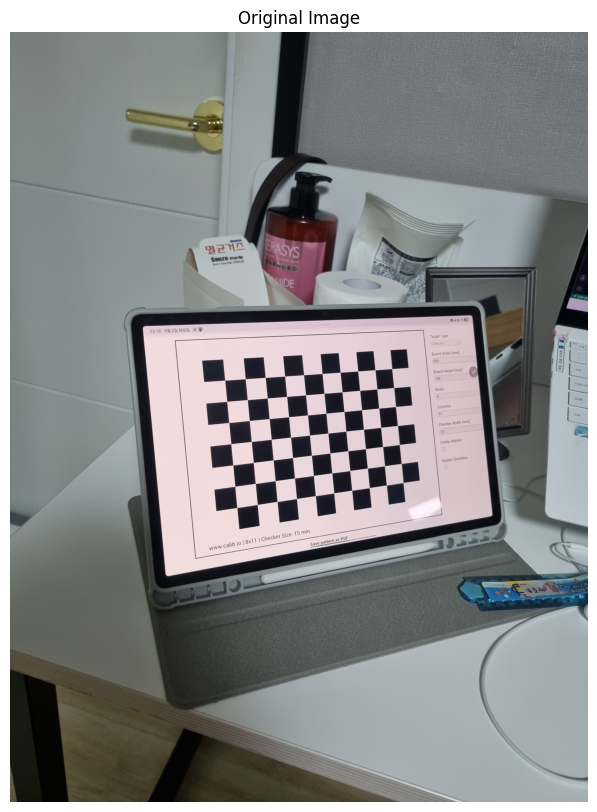

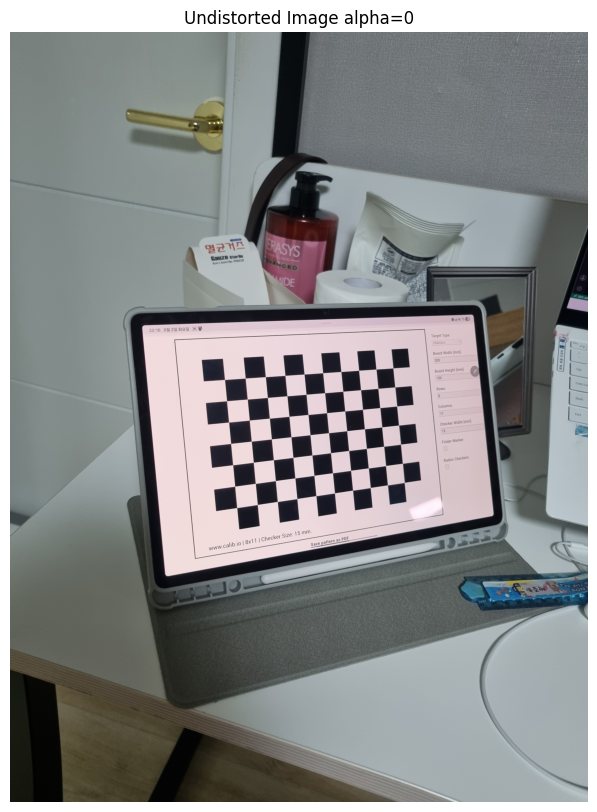

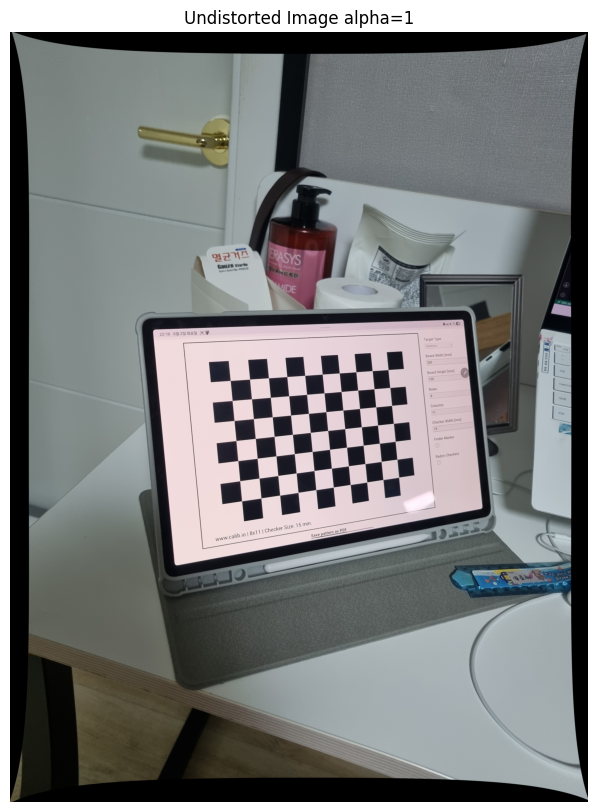

In [16]:
# Code Cell 6: 원본과 보정 이미지 시각화
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
undistorted_alpha0_rgb = cv2.cvtColor(undistorted_alpha0, cv2.COLOR_BGR2RGB)
undistorted_alpha1_rgb = cv2.cvtColor(undistorted_alpha1, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 10))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 10))
plt.imshow(undistorted_alpha0_rgb)
plt.title("Undistorted Image alpha=0")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 10))
plt.imshow(undistorted_alpha1_rgb)
plt.title("Undistorted Image alpha=1")
plt.axis("off")
plt.show()

In [17]:
# Code Cell 7: 원본 / undistorted 나란히 저장
original_save_path = result_dir / f"{test_image_path.stem}_original.jpg"
alpha0_save_path = result_dir / f"{test_image_path.stem}_undistorted_alpha0.jpg"
alpha1_save_path = result_dir / f"{test_image_path.stem}_undistorted_alpha1.jpg"
alpha0_crop_save_path = result_dir / f"{test_image_path.stem}_undistorted_alpha0_cropped.jpg"
alpha1_crop_save_path = result_dir / f"{test_image_path.stem}_undistorted_alpha1_cropped.jpg"

cv2.imwrite(str(original_save_path), img)
cv2.imwrite(str(alpha0_save_path), undistorted_alpha0)
cv2.imwrite(str(alpha1_save_path), undistorted_alpha1)
cv2.imwrite(str(alpha0_crop_save_path), undistorted_alpha0_cropped)
cv2.imwrite(str(alpha1_crop_save_path), undistorted_alpha1_cropped)

print("Saved:")
print(original_save_path)
print(alpha0_save_path)
print(alpha1_save_path)
print(alpha0_crop_save_path)
print(alpha1_crop_save_path)

Saved:
outputs/week2/undistortion/20260602_221616_original.jpg
outputs/week2/undistortion/20260602_221616_undistorted_alpha0.jpg
outputs/week2/undistortion/20260602_221616_undistorted_alpha1.jpg
outputs/week2/undistortion/20260602_221616_undistorted_alpha0_cropped.jpg
outputs/week2/undistortion/20260602_221616_undistorted_alpha1_cropped.jpg


In [18]:
# Code Cell 8: 모든 portrait 이미지 undistort 저장
for image_path in portrait_image_paths:
    img_i = cv2.imread(str(image_path))

    if img_i is None:
        print("Failed to load:", image_path)
        continue

    h_i, w_i = img_i.shape[:2]
    image_size_i = (w_i, h_i)

    if image_size_i != image_size:
        print("Skip size mismatch:", image_path.name, image_size_i)
        continue

    new_camera_matrix_i, roi_i = cv2.getOptimalNewCameraMatrix(
        camera_matrix,
        dist_coeffs,
        image_size_i,
        alpha=0,
        newImgSize=image_size_i
    )

    undistorted_i = cv2.undistort(
        img_i,
        camera_matrix,
        dist_coeffs,
        None,
        new_camera_matrix_i
    )

    x, y, rw, rh = roi_i
    undistorted_crop_i = undistorted_i[y:y+rh, x:x+rw]

    save_full = result_dir / f"{image_path.stem}_undistorted.jpg"
    save_crop = result_dir / f"{image_path.stem}_undistorted_cropped.jpg"

    cv2.imwrite(str(save_full), undistorted_i)
    cv2.imwrite(str(save_crop), undistorted_crop_i)

print("Saved undistorted images to:", result_dir)

Saved undistorted images to: outputs/week2/undistortion


## 5. Undistortion 결과를 해석하는 방법

Undistortion 결과를 볼 때는 다음을 확인한다.

```text
1. 원본 이미지와 비교했을 때 가장자리의 휘어짐이 줄어드는가
2. checkerboard의 직선들이 더 곧게 보이는가
3. alpha=0 결과에서 crop이 발생하는가
4. alpha=1 결과에서 가장자리 검은 영역이 생기는가
5. 보정 후 이미지가 과하게 뒤틀려 보이지 않는가
```
수님의 calibration 결과에서는 reprojection error가 약 0.296 px로 안정적이었다.

따라서 undistortion 결과도 큰 이상 없이 나와야 한다.

다만 휴대폰 카메라 이미지에서 distortion이 아주 심하지 않으면, 원본과 undistorted image 차이가 눈으로 크게 보이지 않을 수도 있다.


## 6. SolvePnP에서 dist_coeffs가 필요한 이유

Week 3에서는 `cv2.solvePnP`를 사용해 object-to-camera pose를 추정한다.

이때 입력은 대략 다음과 같다.

```python
ret, rvec, tvec = cv2.solvePnP(
    object_points,
    image_points,
    camera_matrix,
    dist_coeffs
)
```
여기서 dist_coeffs를 넣는 이유는 실제 image points가 lens distortion의 영향을 받은 pixel 좌표이기 때문이다.

즉, PnP는 다음 관계를 맞추려고 한다.

3D object points
-> R, t
-> camera frame
-> K + dist_coeffs
-> observed image points

만약 distortion이 있는데 dist_coeffs를 무시하면, projected point와 observed point가 어긋날 수 있다.

그 결과 pose의 rvec, tvec도 부정확해질 수 있다.


## 7. 오늘의 핵심 정리

오늘은 Day 4에서 얻은 `camera_matrix`와 `dist_coeffs`를 이용해 image undistortion을 수행했다.

`dist_coeffs`는 실제 렌즈 왜곡을 보정하기 위한 계수이며, 보통 `[k1, k2, p1, p2, k3]` 형태로 해석한다.

`cv2.getOptimalNewCameraMatrix`를 이용해 undistortion에 사용할 새로운 camera matrix와 ROI를 얻었다.

`alpha=0`은 검은 영역을 줄이는 대신 이미지 일부를 crop할 수 있고, `alpha=1`은 원본 시야를 더 보존하지만 가장자리에 검은 영역이 생길 수 있다.

`cv2.undistort`는 원본 이미지, camera matrix, distortion coefficients, new camera matrix를 이용해 lens distortion이 보정된 이미지를 만든다.

이 과정은 Week 3 PnP와도 연결된다.  
PnP에서 `dist_coeffs`를 사용하는 이유는 실제 image points가 lens distortion의 영향을 받은 좌표이기 때문이다.

1. 개념 정의 문제

Q. Image undistortion은 무엇인가?

A.
Image undistortion은 camera matrix K와 distortion coefficients를 이용해 렌즈 왜곡이 포함된 원본 이미지를 이상적인 pinhole camera model에 더 가까운 이미지로 보정하는 과정이다.

Radial distortion은 이미지 중심에서 멀어질수록 생기는 휘어짐을 의미하고, tangential distortion은 렌즈와 이미지 센서가 완벽히 정렬되지 않았을 때 생기는 비대칭 왜곡을 의미한다.

2. 6D Pose Pipeline 연결 문제

Q. dist_coeffs는 Week 3 PnP에서 왜 필요한가?

A.
Raw image에서 검출한 2D image points는 lens distortion의 영향을 받은 좌표이다.

따라서 PnP에서 distortion을 고려하지 않으면 3D object point를 projection했을 때 실제 관측된 2D image point와 어긋나고, 추정된 pose도 부정확해질 수 있다.

단, 이미 undistorted image를 사용한다면 original dist_coeffs를 다시 넣지 않고 new_camera_matrix와 dist_coeffs=None을 사용해야 한다.

raw image + original K + dist_coeffs

또는

undistorted image + new K + dist_coeffs=None
3. 코드 해석 문제

Q. 다음 코드는 무엇을 하는가?

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix,
    dist_coeffs,
    image_size,
    alpha=0,
    newImgSize=image_size
)

A.
cv2.getOptimalNewCameraMatrix는 original camera_matrix와 dist_coeffs를 이용해 undistortion 결과 이미지에서 사용할 새로운 camera matrix와 유효 영역 ROI를 계산한다.

alpha=0은 검은 영역을 최소화하는 설정이므로 이미지가 약간 확대되거나 crop될 수 있다.

roi는 undistortion 후 실제로 유효한 이미지 영역을 나타낸다.

4. 코드 해석 문제

Q. 다음 코드는 무엇을 하는가?

undistorted = cv2.undistort(
    img,
    camera_matrix,
    dist_coeffs,
    None,
    new_camera_matrix
)

A.
cv2.undistort는 원본 이미지 img, original camera_matrix, dist_coeffs, 그리고 new_camera_matrix를 이용해 lens distortion이 보정된 이미지를 생성한다.

즉, 왜곡이 포함된 raw image의 pixel들을 다시 배치해서 이상적인 pinhole camera model에 더 가까운 undistorted image를 만든다.

이때 new_camera_matrix는 undistorted image에서 사용할 새로운 intrinsic matrix 역할을 한다.

5. 디버깅 문제

Q. Undistortion 결과 이미지가 이상하게 휘거나, crop이 너무 심하거나, 검은 영역이 과하게 생겼다. 가능한 원인 3가지를 말하라.

A.
현재 이미지와 맞지 않는 camera_matrix 또는 dist_coeffs를 사용하면 undistortion 결과가 이상해질 수 있다.

예를 들어 다른 해상도, 다른 렌즈, 다른 줌 설정에서 얻은 calibration 결과를 사용하면 보정 결과가 틀어진다.

또한 alpha=1처럼 원본 시야를 많이 보존하는 설정을 사용하면 가장자리에 검은 영역이 크게 생길 수 있다.

마지막으로 calibration 이미지의 blur, reflection, corner detection 오류, pattern_size mismatch 등으로 인해 잘못된 distortion coefficients가 추정되면 undistortion 결과가 과하게 휘거나 crop이 심해질 수 있다.

6. README 설명 문제

Q. 오늘 배운 내용을 README에 3문장으로 설명하라.

A.
Week 2 Day 6에서는 Day 4에서 얻은 camera_matrix와 dist_coeffs를 사용해 image undistortion을 수행했다.

cv2.undistort는 렌즈 왜곡이 포함된 raw image를 이상적인 pinhole camera model에 더 가까운 이미지로 보정하며, cv2.getOptimalNewCameraMatrix는 undistorted image에서 사용할 new_camera_matrix와 유효 영역 ROI를 계산한다.

이번 실험에서 alpha=0은 검은 영역이 거의 없는 결과를 만들었고, alpha=1은 원본 시야를 더 보존하는 대신 가장자리에 검은 영역이 생겼다.

## Day 7: 정리 및 README 업데이트

* 목표

    * 2주차 내용을 실험노트와 README에 정리합니다.

* 할 일

    * Experiment 002 정리
    * camera matrix 정리
    * distortion coefficient 정리
    * reprojection error 결과 정리
    * README에 Week 2 결과 추가
    * 다음 주 PnP로 넘어갈 준비

* 산출물

    * `experiment_log.md` 업데이트
    * `README.md` 업데이트
    * `project_state.md` 업데이트

# Week 2 Day 7: Camera Calibration 정리

## 목표

Week 2 Day 7의 목표는 Week 2에서 수행한 `Camera Calibration` 결과를 README와 실험노트에 정리하는 것이다.

이번 주에는 다음 흐름을 학습했다.

```text
Day 1: Pinhole Camera Model
Day 2: Checkerboard 데이터 준비
Day 3: Corner Detection
Day 4: Camera Calibration
Day 5: Reprojection Error
Day 6: Image Undistortion
Day 7: README / 실험노트 정리
```

---

# README.md 업데이트용 내용

## Camera Calibration

Week 2에서는 Galaxy S21 카메라로 촬영한 checkerboard 이미지를 이용해 camera calibration을 수행했다.

Camera calibration의 목표는 3D point와 2D image point 사이의 projection 관계를 정의하는 camera matrix `K`와 lens distortion을 보정하기 위한 distortion coefficients를 추정하는 것이다.

이 결과는 이후 PnP pose estimation에서 3D object point와 2D image point의 대응으로 object-to-camera pose를 추정할 때 사용된다.

---

## Calibration Setup

| Item | Value |
| --- | --- |
| Camera | Galaxy S21 rear camera |
| Image resolution | `3024 x 4032` |
| Checkerboard squares | `11 x 8` |
| Inner corners | `10 x 7` |
| OpenCV `pattern_size` | `(10, 7)` |
| `square_size` | `15.0 mm` |
| Number of images used | `11` |
| Calibration target | Checkerboard displayed on tablet |

OpenCV에서는 checkerboard의 square 개수가 아니라 inner corner 개수를 `pattern_size`로 사용한다.

따라서 이번 실험에서는 다음 값을 사용했다.

```python
pattern_size = (10, 7)
square_size = 15.0  # mm
```

---

## Pinhole Camera Model

Pinhole camera model은 camera frame의 3D point를 image plane의 2D pixel coordinate로 투영하는 기본 카메라 모델이다.

Camera frame의 3D point를 다음과 같이 둔다.

```text
P_c = [X, Y, Z]
```

Normalized image coordinate는 다음과 같이 계산된다.

```text
x = X / Z
y = Y / Z
```

Camera matrix `K`를 적용하면 pixel coordinate `u, v`를 얻을 수 있다.

```text
u = fx * X / Z + cx
v = fy * Y / Z + cy
```

Camera matrix는 다음 형태이다.

```text
K = [[fx,  0, cx],
     [ 0, fy, cy],
     [ 0,  0,  1]]
```

6D pose estimation pipeline에서는 object frame의 3D point를 object-to-camera pose `T_co`로 camera frame으로 변환한 뒤, camera matrix `K`를 이용해 image coordinate로 projection한다.

```text
P_o -> T_co -> P_c -> K -> p = [u, v]
```

---

## Calibration Result

Calibration 결과 camera matrix는 다음과 같다.

```text
K =
[[3085.9831,    0.0000, 1515.0428],
 [   0.0000, 3082.9837, 2011.0760],
 [   0.0000,    0.0000,    1.0000]]
```

각 intrinsic parameter는 다음과 같다.

| Parameter | Value | Meaning |
| --- | ---: | --- |
| `fx` | `3085.9831` | focal length in x direction |
| `fy` | `3082.9837` | focal length in y direction |
| `cx` | `1515.0428` | principal point x |
| `cy` | `2011.0760` | principal point y |

이미지 크기가 `3024 x 4032`이므로 principal point는 이미지 중심 근처에 위치한다.

Distortion coefficients는 다음과 같다.

```text
dist_coeffs = [0.01643763, 0.14300819, -0.00055302, 0.00087966, -0.35035006]
```

OpenCV 기본 순서에서는 다음과 같이 해석할 수 있다.

```text
[k1, k2, p1, p2, k3]
```

여기서 `k1`, `k2`, `k3`는 radial distortion coefficients이고, `p1`, `p2`는 tangential distortion coefficients이다.

---

## Reprojection Error

Calibration 결과를 평가하기 위해 reprojection error를 계산했다.

Reprojection error는 checkerboard의 3D object points를 추정된 camera parameters와 pose로 다시 image plane에 투영했을 때, 실제 검출된 2D image points와 얼마나 차이 나는지 나타내는 pixel 단위 오차이다.

```text
observed image point  = 실제 이미지에서 검출한 checkerboard corner
projected image point = 3D object point를 다시 이미지 위에 투영한 point
```

실험 결과는 다음과 같다.

| Metric | Value |
| --- | ---: |
| RMS from `cv2.calibrateCamera` | `0.2957 px` |
| Global RMSE reprojection error | `0.2957 px` |
| Worst image RMSE | `0.4342 px` |
| Worst image max error | `1.1083 px` |

Global RMSE가 약 `0.296 px`로 작게 나왔기 때문에, 현재 calibration 결과는 Week 3 PnP 실습에 사용할 수 있을 만큼 안정적이라고 판단했다.

---

## Image Undistortion

Day 6에서는 `camera_matrix`와 `dist_coeffs`를 이용해 image undistortion을 수행했다.

`cv2.undistort`는 렌즈 왜곡이 포함된 raw image를 이상적인 pinhole camera model에 더 가까운 이미지로 보정한다.

또한 `cv2.getOptimalNewCameraMatrix`를 이용해 undistorted image에서 사용할 `new_camera_matrix`와 유효 영역 `ROI`를 계산했다.

`alpha=0` 결과는 다음과 같았다.

```text
ROI alpha=0: (0, 0, 3023, 4031)
```

원본 이미지 크기가 `3024 x 4032`이므로, `alpha=0`에서는 거의 전체 영역을 사용할 수 있었다.

`alpha=1` 결과는 다음과 같았다.

```text
ROI alpha=1: (100, 114, 2833, 3789)
```

`alpha=1`은 원본 시야를 더 많이 보존하기 때문에 가장자리에 검은 영역이 생겼다.

---

## Connection to PnP

Week 3에서는 `cv2.solvePnP`를 이용해 object-to-camera pose를 추정할 예정이다.

이때 사용할 수 있는 방식은 두 가지이다.

```text
raw image + original camera_matrix + dist_coeffs
```

또는

```text
undistorted image + new_camera_matrix + dist_coeffs=None
```

두 방식을 섞으면 중복 보정이 될 수 있으므로 주의해야 한다.

이번 프로젝트에서는 우선 raw image에서 2D image points를 검출하고, original `camera_matrix`와 `dist_coeffs`를 `cv2.solvePnP`에 함께 넣는 방식을 사용할 예정이다.

---

# experiment_log.md 업데이트용 내용

## Week 2 Experiment Log: Camera Calibration

### Goal

이번 주 목표는 Galaxy S21 카메라로 촬영한 checkerboard 이미지를 이용해 camera calibration을 수행하고, Week 3 PnP pose estimation에 사용할 camera parameters를 얻는 것이다.

### Setup

| Item | Value |
| --- | --- |
| Camera | Galaxy S21 rear camera |
| Image resolution | `3024 x 4032` |
| Checkerboard squares | `11 x 8` |
| Inner corners | `10 x 7` |
| `pattern_size` | `(10, 7)` |
| `square_size` | `15.0 mm` |
| Number of images used | `11` |

### Steps

1. Checkerboard image를 촬영했다.
2. `cv2.findChessboardCorners`로 inner corner를 검출했다.
3. `cv2.cornerSubPix`로 corner 위치를 sub-pixel refinement했다.
4. Checkerboard frame 기준 3D object points를 생성했다.
5. `cv2.calibrateCamera`로 camera matrix와 distortion coefficients를 추정했다.
6. `cv2.projectPoints`로 reprojection error를 계산했다.
7. `cv2.undistort`로 image undistortion 결과를 확인했다.

### Results

Camera matrix:

```text
K =
[[3085.9831,    0.0000, 1515.0428],
 [   0.0000, 3082.9837, 2011.0760],
 [   0.0000,    0.0000,    1.0000]]
```

Distortion coefficients:

```text
[0.01643763, 0.14300819, -0.00055302, 0.00087966, -0.35035006]
```

Reprojection error:

```text
RMS from calibrateCamera: 0.2957 px
Global RMSE: 0.2957 px
Worst image RMSE: 0.4342 px
Worst image max error: 1.1083 px
```

Undistortion ROI:

```text
ROI alpha=0: (0, 0, 3023, 4031)
ROI alpha=1: (100, 114, 2833, 3789)
```

### Interpretation

The calibration result is stable enough for the next PnP experiment.

The global reprojection error is below `0.3 px`, and even the worst image has RMSE below `0.5 px`.

In Week 3, I will use the raw image together with the original `camera_matrix` and `dist_coeffs` in `cv2.solvePnP`.

### Next Step

Week 3에서는 3D object points와 2D image points의 correspondence를 만들고, `cv2.solvePnP`를 이용해 object-to-camera pose를 추정한다.

---

# error_log.md 업데이트용 내용

## Week 2 Error Log

### Error 1: OpenCV objectPoints type error

#### Error message

```text
Can't parse 'objectPoints'. Sequence item with index 0 has a wrong type
```

#### Cause

`.npz`로 저장한 `objpoints`, `imgpoints`가 `dtype=object` 형태로 로드되어 OpenCV가 요구하는 float array list 형식과 맞지 않았다.

#### Fix

OpenCV가 받을 수 있도록 각 원소를 `np.float32` array로 변환했다.

```python
objpoints = [np.asarray(p, dtype=np.float32).reshape(-1, 3) for p in objpoints_raw]
imgpoints = [np.asarray(p, dtype=np.float32).reshape(-1, 1, 2) for p in imgpoints_raw]
```

#### Lesson

OpenCV calibration 함수는 입력 array의 dtype과 shape에 민감하다.

`objpoints`는 보통 `(N, 3)` 형태의 `float32` array list이고, `imgpoints`는 `(N, 1, 2)` 형태의 `float32` array list로 맞추는 것이 안전하다.

---

### Error 2: Confusion between square count and inner corner count

#### Problem

Checkerboard의 square 개수와 OpenCV `pattern_size`를 혼동할 수 있다.

#### Cause

OpenCV `findChessboardCorners`는 square 개수가 아니라 내부 corner 개수를 입력으로 받는다.

#### Fix

실제 checkerboard가 `11 x 8` squares이면 inner corners는 `10 x 7`이다.

```python
pattern_size = (10, 7)
```

#### Lesson

OpenCV calibration에서 `pattern_size`는 항상 inner corner 개수이다.

---

### Error 3: Confusion between camera coordinate and image coordinate

#### Problem

`imgpoints`와 `projected_points`를 camera coordinate로 착각할 수 있다.

#### Fix

`imgpoints`와 `projected_points`는 모두 image coordinate의 2D pixel 좌표이다.

```text
imgpoints        = observed 2D image points
projectedPoints  = projected 2D image points
```

Camera coordinate는 3D 좌표이며 다음처럼 표현된다.

```text
P_c = [X, Y, Z]
```

#### Lesson

Calibration과 PnP에서는 3D object points와 2D image points를 명확히 구분해야 한다.

---

### Error 4: Mixing raw image and undistorted image settings

#### Problem

Raw image와 undistorted image에서 사용하는 camera parameters를 혼동할 수 있다.

#### Fix

두 방식 중 하나만 선택한다.

```text
raw image + original camera_matrix + dist_coeffs
```

또는

```text
undistorted image + new_camera_matrix + dist_coeffs=None
```

#### Lesson

이미 undistort된 이미지에 original `dist_coeffs`를 다시 적용하면 중복 보정이 될 수 있다.

---

# glossary.md 업데이트용 내용

## Week 2 Glossary: Camera Model & Calibration

### Pinhole Camera Model

3D camera point를 image plane의 2D point로 투영하는 기본 카메라 모델이다.

### Camera Matrix / Intrinsic Matrix

카메라 내부 파라미터를 담은 행렬이다.

```text
K = [[fx,  0, cx],
     [ 0, fy, cy],
     [ 0,  0,  1]]
```

### `fx`, `fy`

Pixel 단위의 focal length이다.

Normalized image coordinate를 pixel coordinate로 바꾸는 scale 역할을 한다.

### `cx`, `cy`

Principal point의 pixel coordinate이다.

Optical axis가 image plane과 만나는 지점이다.

### Distortion Coefficients

렌즈 왜곡을 설명하는 계수이다.

OpenCV 기본 형태에서는 보통 다음 순서로 사용된다.

```text
[k1, k2, p1, p2, k3]
```

### Radial Distortion

이미지 중심에서 멀어질수록 생기는 휘어짐이다.

### Tangential Distortion

렌즈와 이미지 센서가 완벽히 정렬되지 않았을 때 생기는 비대칭 왜곡이다.

### Checkerboard Inner Corner

Checkerboard 내부에서 검은색과 흰색 square가 만나는 교차점이다.

OpenCV `pattern_size`는 square 개수가 아니라 inner corner 개수이다.

### Object Points

Object frame 또는 checkerboard frame에서 정의한 3D points이다.

### Image Points

이미지에서 검출된 2D pixel points이다.

### Reprojection Error

3D object point를 추정된 camera parameters와 pose로 다시 이미지에 투영했을 때, 실제 관측된 2D point와의 pixel distance이다.

### Undistortion

Camera matrix와 distortion coefficients를 이용해 렌즈 왜곡이 포함된 이미지를 보정하는 과정이다.

### New Camera Matrix

Undistorted image에서 사용할 새로운 intrinsic matrix이다.

### ROI

Region of Interest의 약자이다.

Undistortion 후 실제로 유효한 이미지 영역을 의미한다.

### PnP

Perspective-n-Point의 약자이다.

3D object points와 2D image points의 대응, 그리고 camera parameters를 이용해 object-to-camera pose를 추정하는 방법이다.

---

# Week 2 Final Checklist

- [ ] Checkerboard 설정을 기록했다.
- [ ] `pattern_size = (10, 7)`의 의미를 설명할 수 있다.
- [ ] `square_size = 15.0 mm`의 의미를 설명할 수 있다.
- [ ] `cv2.findChessboardCorners`의 역할을 설명할 수 있다.
- [ ] `cv2.calibrateCamera`의 입력과 출력을 설명할 수 있다.
- [ ] Camera matrix `K`에서 `fx`, `fy`, `cx`, `cy`를 찾을 수 있다.
- [ ] Distortion coefficients `[k1, k2, p1, p2, k3]`를 설명할 수 있다.
- [ ] Reprojection error를 pixel distance로 설명할 수 있다.
- [ ] `cv2.projectPoints`의 역할을 설명할 수 있다.
- [ ] `cv2.undistort`의 역할을 설명할 수 있다.
- [ ] `alpha=0`과 `alpha=1`의 차이를 설명할 수 있다.
- [ ] Raw image와 undistorted image에서 PnP 입력이 어떻게 달라지는지 설명할 수 있다.

---

# Week 3로 넘어가기 전 핵심 문장

Week 2에서는 checkerboard calibration을 통해 camera matrix `K`와 distortion coefficients를 추정했다.

이후 `cv2.projectPoints`로 reprojection error를 계산해 calibration 품질을 확인했고, global RMSE가 약 `0.296 px`로 안정적인 결과를 얻었다.

Week 3에서는 이 camera parameters를 사용해 3D object points와 2D image points의 대응으로 `cv2.solvePnP`를 수행하고, object-to-camera pose를 추정할 예정이다.